# **패키지 관리**

In [3]:
# 데이터 처리 및 전처리
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, RandomOverSampler

# 통계분석 및 진단
import statsmodels.api as sm
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_white, het_breuschpagan
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 데이터 분할 및 모델 선택
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict

# 모델링 및 알고리즘
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, log_evaluation, early_stopping

# 모델 성능평가
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, roc_curve, auc

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import matplotlib.font_manager as fm
from pandas.plotting import scatter_matrix

# 파일 입출력 및 시스템 설정
import os
import joblib
import warnings
warnings.filterwarnings('ignore')


# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic' if 'Malgun Gothic' in [f.name for f in fm.fontManager.ttflist] else 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False 

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [4]:
import os
os.chdir('D:/Git/foodpoision_project/data')

# **Ⅴ. Master Table 모델 검정**

## **1. 지역별 Master Table 선형회귀모델 가정 검정**

#### 1) 지역별 Master Table 선형회귀모델 가정 검정

In [3]:
# 상관관계 확인
region_df = pd.read_csv('Foodborne_Region_MasterTable.csv')

In [4]:
region_df.tail()

,OCCRNC_YEAR,OCCRNC_MM,OCCRNC_REGN,OCCRNC_CNT,PATNT_CNT,OCCRNC_IND,HOL_IND,HOL_DUR,CPI_VALUE,WTHR_AVG_TEMP,...,POP_MID_CNT,POP_HIGH_CNT,POP_60P_CNT,POP_STU_PER_SCH,POP_ELM_RATIO,POP_MID_RATIO,POP_HIGH_RATIO,POP_60P_RATIO,POP_DENS,GMS_LIC_CNT
4153,2002,5,충북,0.0,0.0,0,0,0,68.125,16.8,...,58497.51577,62053.86564,214974.0128,NaN,0.087676,0.039131,0.041510,0.143805,201.154615,7
4154,2002,4,충북,0.0,0.0,0,1,3,67.866,13.0,...,58532.11944,62258.52411,214312.8749,NaN,0.087565,0.039146,0.041638,0.143332,201.197233,4
4155,2002,3,충북,1.0,25.0,1,1,3,67.351,6.9,...,58577.53256,62479.97672,213624.4780,NaN,0.087445,0.039168,0.041777,0.142840,201.241619,6
4156,2002,2,충북,0.0,0.0,0,1,9,67.158,0.3,...,58626.98646,62688.71026,212998.1390,NaN,0.087332,0.039193,0.041908,0.142393,201.282014,6
4157,2002,1,충북,0.0,0.0,0,0,0,66.964,-0.8,...,58691.07841,62929.45336,212299.6423,NaN,0.087202,0.039227,0.042060,0.141894,201.327073,3


In [5]:
region_df.corr(numeric_only = True)

,OCCRNC_YEAR,OCCRNC_MM,OCCRNC_CNT,PATNT_CNT,OCCRNC_IND,HOL_IND,HOL_DUR,CPI_VALUE,WTHR_AVG_TEMP,WTHR_AVG_H_TEMP,...,POP_MID_CNT,POP_HIGH_CNT,POP_60P_CNT,POP_STU_PER_SCH,POP_ELM_RATIO,POP_MID_RATIO,POP_HIGH_RATIO,POP_60P_RATIO,POP_DENS,GMS_LIC_CNT
OCCRNC_YEAR,1.000000,-0.000033,0.076073,-0.044807,0.126291,-0.005972,0.038576,0.980153,0.023912,0.030592,...,-0.165115,-0.118291,0.252899,-0.387663,-0.790056,-0.788385,-0.691580,0.715565,-0.013525,0.002959
OCCRNC_MM,-0.000033,1.000000,0.058346,0.020614,0.039277,-0.023409,-0.068995,0.041748,0.269758,0.262158,...,-0.004512,-0.004801,0.011742,-0.001487,-0.029296,-0.019799,-0.027593,0.035525,-0.000758,-0.062917
OCCRNC_CNT,0.076073,0.058346,1.000000,0.566230,0.597154,0.024265,0.010539,0.081136,0.156899,0.161707,...,0.515249,0.536107,0.495559,0.177081,-0.125955,-0.083102,-0.047549,-0.009007,0.187489,0.445716
PATNT_CNT,-0.044807,0.020614,0.566230,1.000000,0.284821,0.029999,0.029372,-0.045505,0.117494,0.121072,...,0.291862,0.292276,0.244406,0.113301,0.012097,0.012700,-0.002201,-0.069078,0.118950,0.239920
OCCRNC_IND,0.126291,0.039277,0.597154,0.284821,1.000000,0.012051,0.000648,0.135473,0.153345,0.156064,...,0.248958,0.265804,0.305213,0.040683,-0.210434,-0.143742,-0.084638,0.118077,0.139648,0.226033
HOL_IND,-0.005972,-0.023409,0.024265,0.029999,0.012051,1.000000,0.864742,-0.006885,0.078228,0.082684,...,-0.003254,-0.003525,-0.001520,-0.021153,0.011506,-0.013718,-0.016716,-0.003095,-0.000307,-0.043815
HOL_DUR,0.038576,-0.068995,0.010539,0.029372,0.000648,0.864742,1.000000,0.029669,0.002796,0.005752,...,-0.010372,-0.009039,0.010708,-0.031019,-0.012564,-0.049719,-0.051875,0.029511,-0.000661,-0.059860
CPI_VALUE,0.980153,0.041748,0.081136,-0.045505,0.135473,-0.006885,0.029669,1.000000,0.039170,0.047008,...,-0.177331,-0.125736,0.222737,-0.415177,-0.814092,-0.730735,-0.592335,0.691144,-0.040853,0.001066
WTHR_AVG_TEMP,0.023912,0.269758,0.156899,0.117494,0.153345,0.078228,0.002796,0.039170,1.000000,0.992934,...,-0.047868,-0.046248,-0.030074,0.011910,-0.012786,-0.011811,-0.010353,0.012858,0.006023,-0.020210
WTHR_AVG_H_TEMP,0.030592,0.262158,0.161707,0.121072,0.156064,0.082684,0.005752,0.047008,0.992934,1.000000,...,-0.037981,-0.036984,-0.017967,-0.008772,-0.013529,-0.016605,-0.016557,0.026251,-0.019632,-0.002759


In [6]:
region_df = region_df.rename(columns = {'OCCRNC_CNT':'발생건수','PATNT_CNT':'발생환자수','OCCRNC_IND':'발생확률','HOL_DUR':'황금연휴기간','HOL_IND':'황금연휴여부','CPI_VALUE':'소비자물가지수','WTHR_AVG_TEMP':'평균기온'
                          ,'WTHR_AVG_H_TEMP':'평균최고기온','WTHR_AVG_L_TEMP':'평균최저기온','WTHR_AVG_PRECIP':'평균강수량'
                          ,'WTHR_AVG_WNDSPD':'평균풍속','WTHR_MX_WNDSPD':'평균최고풍속','WTHR_AVG_PRESS':'평균기압','WTHR_MX_PRESS':'최고기압'
                          ,'WTHR_MN_PRESS':'최저기압','WTHR_AVG_SEA_PRESS':'평균해면기압','WTHR_MX_SEA_PRESS':'최고해면기압'
                          ,'WTHR_MN_SEA_PRESS':'최저해면기압','WTHR_AVG_RHUM':'평균상대습도','WTHR_MN_RHUM':'최소상대습도','WTHR_SUM_SUNHR':'총일조시간'
                          ,'FST_CNT':'축제횟수','FST_IND':'축제여부','POP_GEN_CNT':'총인구수','POP_ELM_CNT':'초등학생수','POP_MID_CNT':'중학생수'
                          ,'POP_HIGH_CNT':'고등학생수','POP_60P_CNT':'60세이상인구수','POP_ELM_PROB':'초등학생비율','POP_MID_PROB':'중학생비율'
                          ,'POP_HIGH_PROB':'고등학생비율','POP_60P_PROB':'60세이상비율','POP_DENS':'인구밀도','GMS_LIC_CNT':'집단급식소수'})

#### 2) 선형성 검토

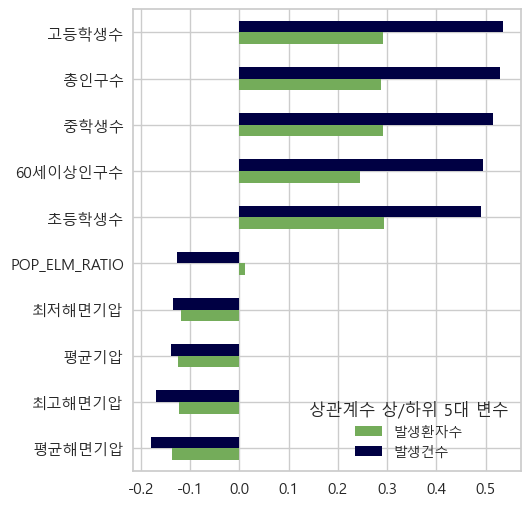

In [7]:
target = region_df.drop(columns = ['OCCRNC_YEAR','OCCRNC_MM','OCCRNC_REGN','POP_STU_PER_SCH']).corr().iloc[:,:2].sort_values(by = '발생건수', ascending = False).iloc[3:,:]
target1 = pd.concat([target.iloc[:5,:], target.iloc[-5:,:]])[['발생환자수','발생건수']]
target1.columns.name = '상관계수 상/하위 5대 변수'
target1.sort_values(by = '발생건수').plot(kind = 'barh', figsize = (5,6), color = ['#74AC5A','#000043'], fontsize = 11)
plt.show()

#### 3) 정규성 검토

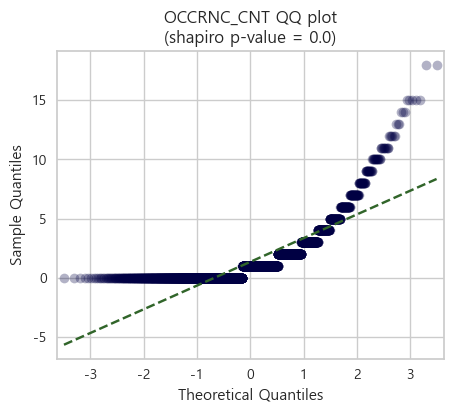

In [8]:
fig, ax = plt.subplots(1, figsize = (5,4))
sm.qqplot(region_df['발생건수'], line = 's', markerfacecolor = '#000043', markeredgecolor = '#000043', alpha = 0.3, ax = ax)
ax.get_lines()[1].set_color('#31652a')
ax.get_lines()[1].set_linestyle('--')
plt.title(f"OCCRNC_CNT QQ plot\n(shapiro p-value = {shapiro(region_df['발생건수']).pvalue})")
plt.show()

#### 4) 등분산성 검토

In [9]:
X = region_df.drop(columns = ['OCCRNC_YEAR','OCCRNC_MM','OCCRNC_REGN','발생환자수','발생건수','발생확률','POP_STU_PER_SCH'])
PATNT_CNT = region_df['발생환자수']
OCCRNC_CNT = region_df['발생건수']

In [10]:
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(X, i) for i in range(len(X.columns))]
vif['Features'] = X.columns

vif.sort_values(by = 'VIF', ascending = False)

,VIF,Features
12,781290.755190,평균해면기압
9,345539.166482,평균기압
13,327874.146145,최고해면기압
14,60505.191554,최저해면기압
3,12241.581779,평균기온
4,5565.176844,평균최고기온
20,2993.136020,총인구수
5,2079.880263,평균최저기온
10,1844.931428,최고기압
23,1063.722292,고등학생수


#### 5) 독립성 검토

In [11]:
def hetero_var_and_independence_test(df):
    X = df.drop(columns = ['OCCRNC_YEAR','OCCRNC_MM','OCCRNC_REGN','발생환자수','발생건수','발생확률','POP_STU_PER_SCH'])
    PATNT_CNT = df['발생환자수']
    OCCRNC_CNT = df['발생건수']
    
    # PATNT_CNT를 종속변수로 했을 경우
    
    X_const = sm.add_constant(X)
    ols_patnt = sm.OLS(endog = PATNT_CNT, exog = X_const).fit()
    
    # OCCRNC_CNT를 종속변수로 했을 경우
    
    ols_occrnc = sm.OLS(endog = OCCRNC_CNT, exog = X_const).fit()

    resid_patnt = ols_patnt.resid
    resid_occrnc = ols_occrnc.resid

    plt.figure(figsize = (12.7, 5))
    plt.subplot(121)
    plt.scatter(ols_patnt.fittedvalues, ols_patnt.resid, color = '#000043', alpha = 0.3)
    plt.xlabel('fitted_values')
    plt.ylabel('residuals')
    plt.title(f'PATNT_CNT 예측값과 잔차의 산점도\n(BP 검정 p-value = {het_breuschpagan(resid = ols_patnt.resid, exog_het = X_const)[3]})')
    
    plt.subplot(122)
    plt.scatter(ols_occrnc.fittedvalues, ols_occrnc.resid, color = '#000043', alpha = 0.3)
    plt.xlabel('fitted_values')
    plt.ylabel('residuals')
    plt.title(f'OCCRNC_CNT 예측값과 잔차의 산점도\n(BP 검정 p-value = {het_breuschpagan(resid = ols_occrnc.resid, exog_het = X_const)[3]})')
    plt.show()
    
    fig, axes = plt.subplots(1,2, figsize = (13, 5))
    plot_acf(resid_patnt, ax = axes[0])
    axes[0].set_title(f'PATNT_CNT 잔차의 ACF \n(DW = {sm.stats.stattools.durbin_watson(resid_patnt):.4f})')

    plot_acf(resid_occrnc, ax = axes[1], color = '#000043', vlines_kwargs={'color':'#000043','linestyle':'-'})
    axes[1].set_title(f'OCCRNC_CNT 잔차의 ACF\n(DW = {sm.stats.stattools.durbin_watson(resid_occrnc):.4f})')
    axes[1].get_lines()[1].set_linestyle('')
    plt.show()

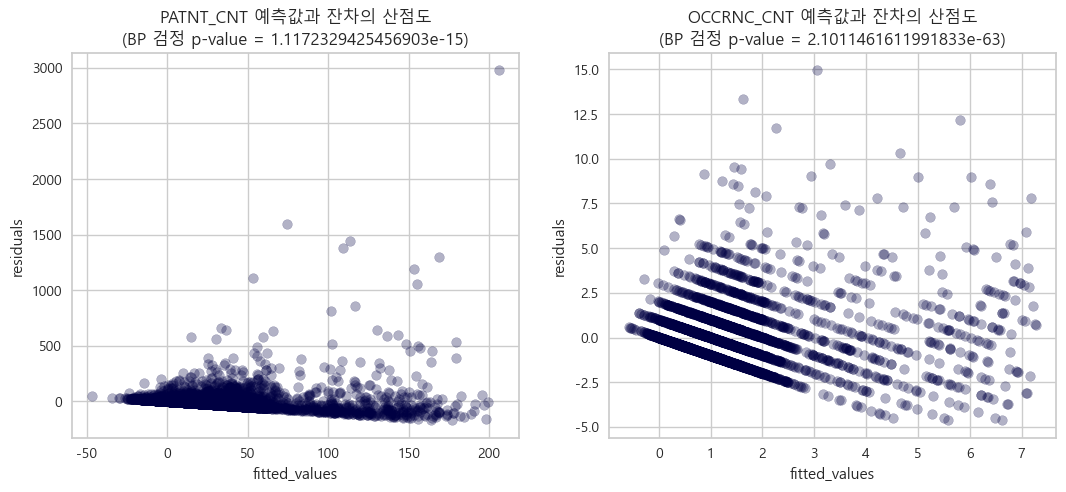

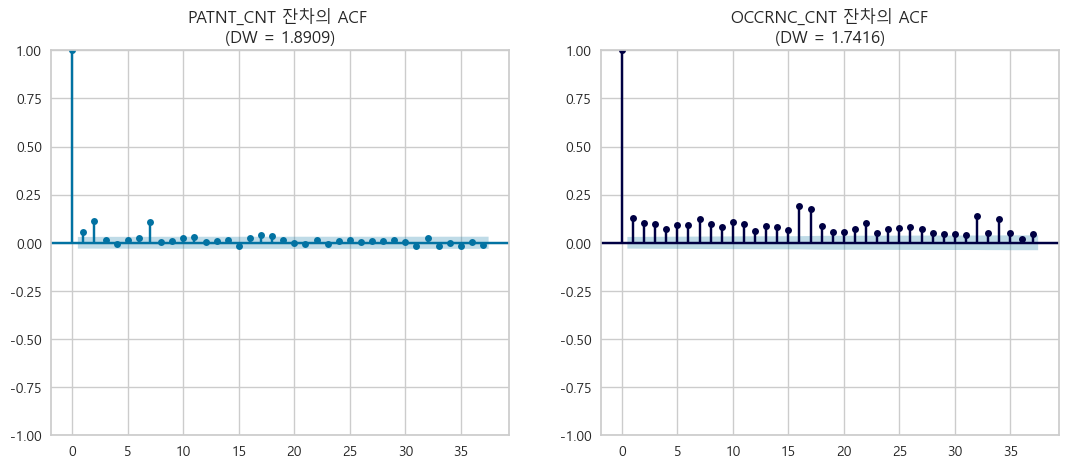

In [12]:
target_df = region_df.sort_values(by = ['OCCRNC_YEAR','OCCRNC_MM'])
hetero_var_and_independence_test(target_df)

#### 6) 결론  
변수 간 공선성이 너무 강해서인지 White검정 실행이 되지 않아 대체 검정법인 Breusch Pagan 검정을 적용했습니다.  
검정 방법은 White검정과 동일하게 등분산성이 없다는 것을 귀무가설로 설정하고 p-value가 유의수준 미만이면 이를 기각하는 형태입니다.  

## 2. Master Table 다층분류모델 가설 검정

- **<다중 분류 기준>**  
**발생 건수 기준 4개의 클래스**
- class0 (발생건수0)
- class1 (발생건수1~5)
- class2 (발생건수6~15)
- class3 (발생건수 15건이상)

#### 1) 지역별 Master Table 다층분류모델 가설 검정

In [13]:
# 데이터 로드
region_data_copy = pd.read_csv('Foodborne_Region_MasterTable.csv')

# 위험 수준을 범주화하는 함수 정의
def risk_category(count):
    if count == 0:
        return 0  # 관심
    elif 1 <= count <= 5:
        return 1  # 주의
    elif 6 <= count <= 15:
        return 2  # 경고
    else:
        return 3  # 위험

# 위험 수준 열 추가
region_data_copy['RISK_LEVEL'] = region_data_copy['OCCRNC_CNT'].apply(risk_category)

# 고유 지역 목록
regions = region_data_copy['OCCRNC_REGN'].unique()

# 모델 정의
models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(objective='multi:softmax', random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

# 결과 저장을 위한 리스트 초기화
all_results = []

# 각 지역과 모델에 대해 평가
for region in regions:
    # 지역별 데이터 필터링
    region_data = region_data_copy[region_data_copy['OCCRNC_REGN'] == region]
    X = region_data.drop(columns=['RISK_LEVEL', 'OCCRNC_CNT', 'OCCRNC_REGN'])
    y = region_data['RISK_LEVEL']

    # 데이터가 너무 적은 경우 건너뛰기
    if y.nunique() < 2:
        print(f"Skipping region {region} due to insufficient data in one or more classes.")
        continue

    # 전처리 단계 설정
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                    ('scaler', StandardScaler())]), numerical_cols),
            ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                                    ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
        ]
    )

    # 데이터셋 분리
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # 데이터 전처리 적용
    X_train_prepared = preprocessor.fit_transform(X_train)
    X_test_prepared = preprocessor.transform(X_test)

    # 각 모델에 대해 학습 및 평가
    for model_name, model in models.items():
        # XGBoost에 대한 num_class 설정
        if model_name == "XGBoost":
            model.set_params(num_class=len(y.unique()))

        # 모델 학습 및 예측
        model.fit(X_train_prepared, y_train)
        y_pred = model.predict(X_test_prepared)

        # 클래스별 precision, recall, f1-score 계산
        for cls in sorted(y.unique()):
            precision = precision_score(y_test, y_pred, labels=[cls], average='weighted', zero_division=0)
            recall = recall_score(y_test, y_pred, labels=[cls], average='weighted', zero_division=0)
            f1 = f1_score(y_test, y_pred, labels=[cls], average='weighted', zero_division=0)

            # Accuracy는 전체에 대해 한 번만 계산
            accuracy = accuracy_score(y_test, y_pred) if cls == 0 else None

            # 결과 저장
            all_results.append({
                'Region': region,
                'Model': model_name,
                'Class': cls,
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1 Score': f1
            })

# 결과를 데이터프레임으로 변환 및 출력
results_df = pd.DataFrame(all_results)
results_df.head()

,Region,Model,Class,Accuracy,Precision,Recall,F1 Score
0,강원,RandomForest,0,0.947368,1.000000,1.000000,1.000000
1,강원,RandomForest,1,NaN,0.976744,0.933333,0.954545
2,강원,RandomForest,2,NaN,0.000000,0.000000,0.000000
3,강원,XGBoost,0,0.947368,1.000000,1.000000,1.000000
4,강원,XGBoost,1,NaN,0.976744,0.933333,0.954545


#### 2) 원인물질별 Master Table 다층분류모델 가설 검정

In [14]:
# 데이터 로드
data_cause_copy = pd.read_csv('Foodborne_Cause_MasterTable4.csv')

# 위험 수준을 범주화하는 함수 정의
def risk_category(count):
    if count == 0:
        return 0  # 관심
    elif 1 <= count <= 5:
        return 1  # 주의
    elif 6 <= count <= 15:
        return 2  # 경고
    else:
        return 3  # 위험

# 위험 수준 열 추가
data_cause_copy['RISK_LEVEL'] = data_cause_copy['OCCRNC_CNT'].apply(risk_category)

# 고유 바이러스 목록
viruses = data_cause_copy['OCCRNC_VIRS'].unique()

# 모델 정의
models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(objective='multi:softmax', random_state=42),  # XGBoost의 num_class 설정은 아래에서 적용
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

# 결과 저장을 위한 리스트 초기화
all_results = []

# 각 바이러스와 모델에 대해 평가
for virus in viruses:
    # 바이러스별 데이터 필터링
    virus_data = data_cause_copy[data_cause_copy['OCCRNC_VIRS'] == virus]
    X = virus_data.drop(columns=['RISK_LEVEL', 'OCCRNC_CNT'])
    y = virus_data['RISK_LEVEL']

    # 전처리 단계 설정
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                    ('scaler', StandardScaler())]), numerical_cols),
            ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                                    ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
        ]
    )

    # 데이터셋 분리
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # 데이터 전처리 적용
    X_train_prepared = preprocessor.fit_transform(X_train)
    X_test_prepared = preprocessor.transform(X_test)

    # 각 모델에 대해 학습 및 평가
    for model_name, model in models.items():
        # XGBoost에 대한 num_class 설정
        if model_name == "XGBoost":
            model.set_params(num_class=len(y.unique()))

        # 모델 학습 및 예측
        model.fit(X_train_prepared, y_train)
        y_pred = model.predict(X_test_prepared)

        # 클래스별 precision, recall, f1-score 계산
        for cls in sorted(y.unique()):
            precision = precision_score(y_test, y_pred, labels=[cls], average='weighted', zero_division=0)
            recall = recall_score(y_test, y_pred, labels=[cls], average='weighted', zero_division=0)
            f1 = f1_score(y_test, y_pred, labels=[cls], average='weighted', zero_division=0)

            # Accuracy는 전체에 대해 한 번만 계산
            accuracy = accuracy_score(y_test, y_pred) if cls == 0 else None

            # 결과 저장
            all_results.append({
                'Virus': virus,
                'Model': model_name,
                'Class': cls,
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1 Score': f1
            })

# 결과를 데이터프레임으로 변환 및 출력
results_df = pd.DataFrame(all_results)
results_df

,Virus,Model,Class,Accuracy,Precision,Recall,F1 Score
0,노로바이러스,RandomForest,0,0.828947,1.000000,1.000000,1.000000
1,노로바이러스,RandomForest,1,NaN,0.833333,0.909091,0.869565
2,노로바이러스,RandomForest,2,NaN,0.375000,0.272727,0.315789
3,노로바이러스,RandomForest,3,NaN,0.000000,0.000000,0.000000
4,노로바이러스,XGBoost,0,0.815789,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...
198,황색포도상구균,NaiveBayes,1,NaN,0.970588,1.000000,0.985075
199,황색포도상구균,NaiveBayes,2,NaN,0.000000,0.000000,0.000000
200,황색포도상구균,DecisionTree,0,0.986842,1.000000,1.000000,1.000000
201,황색포도상구균,DecisionTree,1,NaN,0.970588,1.000000,0.985075


# **Ⅵ. Master Table 모델링**

## 1. PYCarot

In [15]:
master_df = pd.read_csv('Foodborne_Cause_MasterTable4.csv')
# 지역을 기준으로 그룹화해서 지역별 데이터셋 생성
cause_groups = {cause: df for cause, df in master_df.groupby('OCCRNC_VIRS')}

norovirs_df = cause_groups.get("노로바이러스")
bacillus_df = cause_groups.get("바실러스세레우스")
ecoli_df = cause_groups.get("병원성대장균")
salmonella_df = cause_groups.get("살모넬라")
protozoa_df = cause_groups.get("원충")
vibrio_df = cause_groups.get("장염비브리오")
campilobacter_df = cause_groups.get("캠필로박터제주니")
clostrip_df = cause_groups.get("클로스트리디움퍼프린젠스")
staphylo_df = cause_groups.get("황색포도상구균")

# 원인물질별 데이터프레임 목록
cause_list = {
    "노로바이러스": ["norovirs", norovirs_df],
    "바실러스세레우스": ["bacillus", bacillus_df],
    "병원성대장균": ["ecoli", ecoli_df],
    "살모넬라": ["salmonella", salmonella_df],
    "원충": ["protozoa", protozoa_df],
    "장염비브리오": ["vibrio", vibrio_df],
    "캠필로박터제주니": ["campilobacter", campilobacter_df],
    "클로스트리디움퍼프린젠스": ["clostrip", clostrip_df],
    "황색포도상구균": ["staphylo", staphylo_df]
}

#### 1) PyCaret Classification 분석

In [16]:
# 최종 결과를 저장할 데이터프레임 생성
final_report = pd.DataFrame()
removed_features_report = {}

for cause_name, (eng_name, cause_df) in cause_list.items():
    print(f"Processing {cause_name} ...")

    # PyCaret 설정
    classification_setup = setup(
        data=cause_df,
        target='OCCRNC_IND',  
        ignore_features=['OCCRNC_CNT', 'PATNT_CNT', 'OCCRNC_VIRS', 'OCCRNC_YEAR', 'OCCRNC_MM'],  
        session_id=42,
        #normalize=True,
        #feature_selection=True,
        #remove_multicollinearity=True,
        #multicollinearity_threshold=0.9,
        remove_outliers=False,
        fold=5,  
        train_size=0.7,
        html=False,
        #fix_imbalance=True
    )

    # 모델 비교 수행 및 결과 가져오기
    models = compare_models(verbose=False)
    results = pull()
    
    # 사용 가능한 지표 확인
    print(f"Available metrics in results for {cause_name}: {results.columns}")
    
    # 존재하는 지표로만 필터링
    available_metrics = ['Accuracy', 'F1', 'Recall', 'Prec.']
    metrics = [metric for metric in available_metrics if metric in results.columns]
    
    if 'Model' in results.columns:
        results_sorted = results[['Model'] + metrics].sort_values(by='Model').set_index('Model')
    else:
        # 'Model' 열이 없을 경우 직접적인 모델 이름 사용 대신 index 설정 필요
        results_sorted = results[metrics].sort_index()
    
    # 각 원인물질에 대한 성능 지표를 final_report에 추가
    for metric in metrics:
        final_report[f"{cause_name}_{metric}"] = results_sorted[metric]

# # 최종 보고서 저장
# final_report.to_csv('PyCaret_Cause4_Classification_ver1.csv', encoding='utf-8-sig')

print("Process Terminated")


Processing 노로바이러스 ...
                    Description             Value
0                    Session id                42
1                        Target        OCCRNC_IND
2                   Target type            Binary
3           Original data shape         (252, 37)
4        Transformed data shape         (252, 32)
5   Transformed train set shape         (176, 32)
6    Transformed test set shape          (76, 32)
7               Ignore features                 5
8              Numeric features                31
9                    Preprocess              True
10              Imputation type            simple
11           Numeric imputation              mean
12       Categorical imputation              mode
13               Fold Generator   StratifiedKFold
14                  Fold Number                 5
15                     CPU Jobs                -1
16                      Use GPU             False
17               Log Experiment             False
18              Experiment N

### 2) XGBoost Classifier 분석

In [17]:
results = []
drop_cols = ['OCCRNC_IND','OCCRNC_CNT', 'PATNT_CNT', 'OCCRNC_VIRS', 'OCCRNC_YEAR', 'OCCRNC_MM']

for cause_name, (cause_code, cause_df) in cause_list.items():
    # 독립 변수(X)와 종속 변수(y) 분리
    X = cause_df.drop(columns=drop_cols)
    y = cause_df['OCCRNC_IND']    

    # 데이터 분할 (train 70%, test 30%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # 모델 생성 및 학습
    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    model.fit(X_train, y_train)

    # 모델 저장
    model_filename = f"{cause_name}_XGBoost_model.joblib"
    joblib.dump(model, model_filename)
    
    
    # 예측
    y_pred = model.predict(X_test)

    # 평가지표 계산
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    precision = precision_score(y_test, y_pred, zero_division=0)
    
    # 결과 저장
    results.append({
        'Cause': cause_name,
        'Accuracy': round(accuracy, 4),
        'F1 Score': round(f1, 4),
        'Recall': round(recall, 4),
        'Precision': round(precision, 4)
    })

# 결과를 DataFrame으로 변환 및 CSV로 저장
results_df = pd.DataFrame(results)
results_df.head(3)
# results_df.to_csv('XGBoost_Cause4_1.csv', index=False, encoding='utf-8-sig')


,Cause,Accuracy,F1 Score,Recall,Precision
0,노로바이러스,0.7632,0.8475,0.8929,0.8065
1,바실러스세레우스,0.6842,0.5000,0.5455,0.4615
2,병원성대장균,0.8289,0.8713,0.8800,0.8627


#### 3) Results and Discussion

1. Gradient Boosting Regressor (gbr)
    - 여러 지역에서 상대적으론 높은 R(^)2 값을 기록하고 있다.
    - 비선형 모델로 데이터 내의 복잡한 패턴을 파악하는데 유리하다
    - 해석 가능성은 다소 낮지만, feature importance 등을 통해 중요한 변수들을 파악할 수 있다.

2. Light Gradient Boosting Machine (lightgbm)
    - XGBoost와 유사한 앙상블 학습 모델이지만, 속도가 빠르고 메모리 효율이 좋다.
    - 일부 지역에서 상대적으로 높은 R(^)2 값을 기록하고 있다.

3. Random Forest Regressor
    - '경남', '부산', '강원' 등에서 비교적 준수한 성능을 보인다.
    - 비선형 패턴을 작 학습할 수 있기 때문에 다양한 변수 간의 상호작용을 포착할 수 있다.
    - 추가적인 하이퍼파라미터 튜닝 시 성능 향상의 여지가 크다.
    - 해석은 다소 어렵겠지만, 변수 중요도 분석을 통해 주요 변수를 파악할 수 있다.

4. Extra Trees Regressor
    - Random Forest 와 비슷하지만, 더욱 무작위성을 강조하여 특정 피처의 임의의 분할지점을 사용하기 때문에 과적합 방지에 더 효과적이다.
    - 비선형성 및 복잡한 데이터 패턴 학습에 강하다.
    - 랜덤한 특성으로 인해 데이터의 노이즈에 잘 견딜 수 있기 때문에 데이터에 노이즈가 많거나 불확실한 경우 장점으로 작용될 수 있다.
    - 하이퍼파라미터 조정을 통해 성능을 향상시키기 쉬운 편이다.

**결론:** Gradient Boosting Regressor, LGBM, XGBoost, Random Forest Regressor, Extra Trees Regressor 모델을 이용하여 추가 분석 수행.

## 2. 지역별 식중독 예측 모델링

### 1) 모델링

#### - 최초 모델

In [6]:
data = pd.read_csv(r'Foodborne_Region_MasterTable.csv')
# 종속변수 OCCRNC_IND와 관련된 변수 OCCRNC_CNT, OCCRNC_REGN, PATNT_CNT와 결측치가 많은 변수 POP_STU_PER_SCH는 제외하고 모델링 
# OCCRNC_YEAR, OCCRNC_MM도 독립변수에서 제외한 모델과 비교 

city = ['강원', '경기', '경남', '경북', '광주', '대구', '대전', '부산', '서울', '세종', '울산', '인천', '전남', '전북', '제주', '충남', '충북']
models = {
    'RF': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGB': XGBClassifier(n_estimators=100, learning_rate=0.3, max_depth=6, random_state=42),
    'GB': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

results = []

for c in city:
    filtered_data = data[data['OCCRNC_REGN'] == c]
    X = filtered_data.drop(columns=['OCCRNC_CNT', 'OCCRNC_REGN', 'OCCRNC_IND', 'PATNT_CNT', 'POP_STU_PER_SCH']) 
    y = filtered_data['OCCRNC_IND']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
    
    city_results = {'City': c}

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        
        # Feature Importance
        importance = dict(sorted(zip(X.columns, model.feature_importances_), key=lambda item: item[1], reverse=True)[:5])

        # Validation performance
        y_val_pred = model.predict(X_val)
        city_results.update({
            f'{model_name}_Val_Accuracy': round(accuracy_score(y_val, y_val_pred), 4),
            f'{model_name}_Val_F1_Score': round(f1_score(y_val, y_val_pred), 4),
            f'{model_name}_Val_Precision': round(precision_score(y_val, y_val_pred), 4),
            f'{model_name}_Val_Recall': round(recall_score(y_val, y_val_pred), 4)
        })
        
        # Test performance
        y_test_pred = model.predict(X_test)
        city_results.update({
            f'{model_name}_T_Accuracy': round(accuracy_score(y_test, y_test_pred), 4),
            f'{model_name}_T_F1_Score': round(f1_score(y_test, y_test_pred), 4),
            f'{model_name}_T_Precision': round(precision_score(y_test, y_test_pred), 4),
            f'{model_name}_T_Recall': round(recall_score(y_test, y_test_pred), 4)
        })

    results.append(city_results)

# Convert to DataFrame and save to CSV
results_df = pd.DataFrame(results)
results_df.head(3)

,City,RF_Val_Accuracy,RF_Val_F1_Score,RF_Val_Precision,RF_Val_Recall,RF_T_Accuracy,RF_T_F1_Score,RF_T_Precision,RF_T_Recall,XGB_Val_Accuracy,...,XGB_T_Precision,XGB_T_Recall,GB_Val_Accuracy,GB_Val_F1_Score,GB_Val_Precision,GB_Val_Recall,GB_T_Accuracy,GB_T_F1_Score,GB_T_Precision,GB_T_Recall
0,강원,0.7222,0.7727,0.7391,0.8095,0.6579,0.6579,0.7812,0.5682,0.6944,...,0.7297,0.6136,0.6389,0.7111,0.6667,0.7619,0.5921,0.6265,0.6667,0.5909
1,경기,0.7500,0.8525,0.9286,0.7879,0.8684,0.9275,0.9275,0.9275,0.8056,...,0.9000,0.9130,0.8056,0.8852,0.9643,0.8182,0.8684,0.9265,0.9403,0.9130
2,경남,0.6667,0.7273,0.6667,0.8000,0.7368,0.7619,0.7805,0.7442,0.6944,...,0.6809,0.7442,0.5833,0.6667,0.6000,0.7500,0.7895,0.8140,0.8140,0.8140


#### - 최종 모델

강원   
(Gradient 모델/ 오버샘플링 미적용 / n_estimators 20, learning_rate 0.09, max_depth 7)

In [7]:
filtered = data[data['OCCRNC_REGN'] == '강원']
X = filtered.drop(columns=['OCCRNC_YEAR', 'OCCRNC_MM', 'OCCRNC_CNT', 'OCCRNC_REGN', 'OCCRNC_IND', 'PATNT_CNT', 'POP_STU_PER_SCH', 'GMS_LIC_CNT','POP_MID_RATIO', 'WTHR_AVG_RHUM', 'WTHR_MN_RHUM', 'FST_IND', 'POP_MID_CNT', 'POP_60P_CNT', 'POP_60P_RATIO', 'HOL_IND', 'FST_CNT'])
y = filtered['OCCRNC_IND']

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# 하이퍼 파라미터 그리드 설정
param_grid = {
    'n_estimators': [20],
    'learning_rate': [0.09],
    'max_depth': [17],
}

# GridSearchCV 설정 및 최적의 파라미터 찾기
gb_model = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(estimator=gb_model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# print("Best parameters found: ", grid_search.best_params_)
# print("Best cross-validation F1 score: {:.4f}".format(grid_search.best_score_))

# 최적의 모델로 평가
best_gb_model = grid_search.best_estimator_

# 검증 세트 성능 평가
y_val_pred_GB = best_gb_model.predict(X_val)
val_Accuracy_GB = round(accuracy_score(y_val, y_val_pred_GB), 4)
val_f1_GB = round(f1_score(y_val, y_val_pred_GB), 4)
val_precision_GB = round(precision_score(y_val, y_val_pred_GB), 4)
val_recall_GB = round(recall_score(y_val, y_val_pred_GB), 4)

# 테스트 세트 성능 평가
y_test_pred_GB = best_gb_model.predict(X_test)
test_Accuracy_GB = round(accuracy_score(y_test, y_test_pred_GB), 4)
test_f1_GB = round(f1_score(y_test, y_test_pred_GB), 4)
test_precision_GB = round(precision_score(y_test, y_test_pred_GB), 4)
test_recall_GB = round(recall_score(y_test, y_test_pred_GB), 4)


print(f'City', '강원')
print(f"{val_Accuracy_GB} {val_f1_GB} {val_precision_GB} {val_recall_GB} {test_Accuracy_GB} {test_f1_GB} {test_precision_GB} {test_recall_GB}")

# 모델 저장
model_filename = f"강원_{best_gb_model.__class__.__name__}.pkl"
joblib.dump(best_gb_model, model_filename)


Fitting 5 folds for each of 1 candidates, totalling 5 fits
City 강원
0.6111 0.65 0.6842 0.619 0.6711 0.6988 0.7436 0.6591


['강원_GradientBoostingClassifier.pkl']

경기  
(Gradient 모델/ SMOTE 오버샘플링/ n_estimators 100, learning_rate 0.1, max_depth 5)


In [8]:
filtered = data[data['OCCRNC_REGN'] == '경기']
X = filtered.drop(columns=['OCCRNC_YEAR', 'OCCRNC_MM', 'OCCRNC_CNT', 'OCCRNC_REGN', 'OCCRNC_IND', 'PATNT_CNT', 'POP_STU_PER_SCH'])
y = filtered['OCCRNC_IND']

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [5],
}

# GridSearchCV 설정 및 최적의 파라미터 찾기
gb_model = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(estimator=gb_model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train_smote, y_train_smote)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation F1 score: {:.4f}".format(grid_search.best_score_))

# 최적의 모델로 평가
best_gb_model = grid_search.best_estimator_

# 검증 세트 성능 평가
y_val_pred_GB = best_gb_model.predict(X_val)
val_Accuracy_GB = round(accuracy_score(y_val, y_val_pred_GB), 4)
val_f1_GB = round(f1_score(y_val, y_val_pred_GB), 4)
val_precision_GB = round(precision_score(y_val, y_val_pred_GB), 4)
val_recall_GB = round(recall_score(y_val, y_val_pred_GB), 4)

# 테스트 세트 성능 평가
y_test_pred_GB = best_gb_model.predict(X_test)
test_Accuracy_GB = round(accuracy_score(y_test, y_test_pred_GB), 4)
test_f1_GB = round(f1_score(y_test, y_test_pred_GB), 4)
test_precision_GB = round(precision_score(y_test, y_test_pred_GB), 4)
test_recall_GB = round(recall_score(y_test, y_test_pred_GB), 4)


print(f'City', '경기')
print(f'GB_Validation_Accuracy: {val_Accuracy_GB}'),
print(f'GB_Validation_F1_Score: {val_f1_GB}'),
print(f'GB_Validation_Precision: {val_precision_GB}'),
print(f'GB_Validation_Recall: {val_recall_GB}'),
print(f'GB_Test_Accuracy: {test_Accuracy_GB}'),
print(f'GB_Test_F1_Score: {test_f1_GB}'),
print(f'GB_Test_Precision: {test_precision_GB}'),
print(f'GB_Test_Recall: {test_recall_GB}')

# 모델 저장
model_filename = f"경기 {best_gb_model.__class__.__name__}.pkl"
joblib.dump(best_gb_model, model_filename)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters found:  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best cross-validation F1 score: 0.9434
City 경기
GB_Validation_Accuracy: 0.7222
GB_Validation_F1_Score: 0.8387
GB_Validation_Precision: 0.8966
GB_Validation_Recall: 0.7879
GB_Test_Accuracy: 0.9211
GB_Test_F1_Score: 0.9565
GB_Test_Precision: 0.9565
GB_Test_Recall: 0.9565


['경기 GradientBoostingClassifier.pkl']

경남  
(LightGBM 모델/ 오버샘플링 미적용 / n_estimators 100, learning_rate 0.1, max_depth -1, min_child_samples 20, num_leaves 31, subsample 1)

In [9]:
filtered = data[data['OCCRNC_REGN'] == '경남']
X = filtered.drop(columns=['OCCRNC_CNT', 'OCCRNC_REGN', 'OCCRNC_IND', 'PATNT_CNT', 'POP_STU_PER_SCH'])
y = filtered['OCCRNC_IND']

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [-1],
    'min_child_samples': [20],
    'num_leaves': [31],
    'subsample': [1]
}

# GridSearchCV 설정 및 최적의 파라미터 찾기
lgb_model = LGBMClassifier(random_state=42)
grid_search = GridSearchCV(estimator=lgb_model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='f1',  callbacks=[early_stopping(stopping_rounds=50), log_evaluation(period=10)])

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation F1 score: {:.4f}".format(grid_search.best_score_))

# 최적의 모델로 평가
best_lgb_model = grid_search.best_estimator_

# LGB Validation 성능 평가: 
y_val_pred_LGB = best_lgb_model.predict(X_val)
val_Accuracy_LGB = round(accuracy_score(y_val, y_val_pred_LGB), 4)
val_f1_LGB = round(f1_score(y_val, y_val_pred_LGB), 4)
val_precision_LGB = round(precision_score(y_val, y_val_pred_LGB), 4)
val_recall_LGB = round(recall_score(y_val, y_val_pred_LGB), 4)

# LGB Test 데이터 성능평가: 
y_test_pred_LGB = best_lgb_model.predict(X_test)
test_Accuracy_LGB = round(accuracy_score(y_test, y_test_pred_LGB), 4)
test_f1_LGB = round(f1_score(y_test, y_test_pred_LGB), 4)
test_precision_LGB = round(precision_score(y_test, y_test_pred_LGB), 4)
test_recall_LGB = round(recall_score(y_test, y_test_pred_LGB), 4)

print(f'City', '경남')
print(f'GB_Validation_Accuracy: {val_Accuracy_LGB}'),
print(f'GB_Validation_F1_Score: {val_f1_LGB}'),
print(f'GB_Validation_Precision: {val_precision_LGB}'),
print(f'GB_Validation_Recall: {val_recall_LGB}'),
print(f'GB_Test_Accuracy: {test_Accuracy_LGB}'),
print(f'GB_Test_F1_Score: {test_f1_LGB}'),
print(f'GB_Test_Precision: {test_precision_LGB}'),
print(f'GB_Test_Recall: {test_recall_LGB}')
print(f"{grid_search.best_params_} {val_Accuracy_LGB} {val_f1_LGB} {val_precision_LGB} {val_recall_LGB} {test_Accuracy_LGB} {test_f1_LGB} {test_precision_LGB} {test_recall_LGB}")

model_filename = f"경남 {best_lgb_model.__class__.__name__}.pkl"
joblib.dump(best_lgb_model, model_filename)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[LightGBM] [Info] Number of positive: 79, number of negative: 61
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000328 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1202
[LightGBM] [Info] Number of data points in the train set: 140, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.564286 -> initscore=0.258574
[LightGBM] [Info] Start training from score 0.258574
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

['경남 LGBMClassifier.pkl']

경북  
(Gradient 모델/ Random 오버샘플링 적용/ n_estimators 100, learning_rate 0.1, max_depth 3,subsample 1)

In [10]:
filtered = data[data['OCCRNC_REGN'] == '경북']
X = filtered.drop(columns=['OCCRNC_CNT', 'OCCRNC_REGN', 'OCCRNC_IND', 'PATNT_CNT', 'POP_STU_PER_SCH'])
y = filtered['OCCRNC_IND']

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

ros = RandomOverSampler(random_state=42)
X_ros_resampled, y_ros_resampled = ros.fit_resample(X_train, y_train)


# 하이퍼 파라미터 그리드 설정
param_grid = {
    'n_estimators': [90],
    'learning_rate': [0.1],
    'max_depth': [5],
}

# GridSearchCV 설정 및 최적의 파라미터 찾기
gb_model = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(estimator=gb_model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_ros_resampled, y_ros_resampled)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation F1 score: {:.4f}".format(grid_search.best_score_))

# 최적의 모델로 평가
best_gb_model = grid_search.best_estimator_

# 검증 세트 성능 평가
y_val_pred_GB = best_gb_model.predict(X_val)
val_Accuracy_GB = round(accuracy_score(y_val, y_val_pred_GB), 4)
val_f1_GB = round(f1_score(y_val, y_val_pred_GB), 4)
val_precision_GB = round(precision_score(y_val, y_val_pred_GB), 4)
val_recall_GB = round(recall_score(y_val, y_val_pred_GB), 4)

# 테스트 세트 성능 평가
y_test_pred_GB = best_gb_model.predict(X_test)
test_Accuracy_GB = round(accuracy_score(y_test, y_test_pred_GB), 4)
test_f1_GB = round(f1_score(y_test, y_test_pred_GB), 4)
test_precision_GB = round(precision_score(y_test, y_test_pred_GB), 4)
test_recall_GB = round(recall_score(y_test, y_test_pred_GB), 4)


print(f'City', '경북')
print(f'GB_Validation_Accuracy: {val_Accuracy_GB}'),
print(f'GB_Validation_F1_Score: {val_f1_GB}'),
print(f'GB_Validation_Precision: {val_precision_GB}'),
print(f'GB_Validation_Recall: {val_recall_GB}'),
print(f'GB_Test_Accuracy: {test_Accuracy_GB}'),
print(f'GB_Test_F1_Score: {test_f1_GB}'),
print(f'GB_Test_Precision: {test_precision_GB}'),
print(f'GB_Test_Recall: {test_recall_GB}')
print(f"{grid_search.best_params_} {val_Accuracy_GB} {val_f1_GB} {val_precision_GB} {val_recall_GB} {test_Accuracy_GB} {test_f1_GB} {test_precision_GB} {test_recall_GB}")

model_filename = f"경북 {best_gb_model.__class__.__name__}.pkl"
joblib.dump(best_gb_model, model_filename)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters found:  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 90}
Best cross-validation F1 score: 0.7269
City 경북
GB_Validation_Accuracy: 0.7222
GB_Validation_F1_Score: 0.7727
GB_Validation_Precision: 0.7727
GB_Validation_Recall: 0.7727
GB_Test_Accuracy: 0.6974
GB_Test_F1_Score: 0.7677
GB_Test_Precision: 0.7308
GB_Test_Recall: 0.8085
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 90} 0.7222 0.7727 0.7727 0.7727 0.6974 0.7677 0.7308 0.8085


['경북 GradientBoostingClassifier.pkl']

광주  
(LightGGBM 모델/ SMOTE 오버샘플링 적용/ n_estimators 300, learning_rate 0.5, max_depth 2, min_child_samples 20, num_leaves 31, subsample 1)

In [11]:
filtered = data[data['OCCRNC_REGN'] == '광주']
X = filtered.drop(columns=['OCCRNC_YEAR', 'OCCRNC_MM', 'OCCRNC_CNT', 'OCCRNC_REGN', 'OCCRNC_IND', 'PATNT_CNT', 'POP_STU_PER_SCH'])
y = filtered['OCCRNC_IND']

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

smote = SMOTE(random_state=42)
X_smote_resampled, y_smote_resampled = smote.fit_resample(X_train, y_train)

param_grid = {
    'n_estimators': [300],
    'learning_rate': [0.5],
    'max_depth': [2],
}

# GridSearchCV 설정 및 최적의 파라미터 찾기
lgb_model = LGBMClassifier(random_state=42)
grid_search = GridSearchCV(estimator=lgb_model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_smote_resampled, y_smote_resampled, eval_set=[(X_val, y_val)], eval_metric='f1',  callbacks=[early_stopping(stopping_rounds=50), log_evaluation(period=10)])

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation F1 score: {:.4f}".format(grid_search.best_score_))

# 최적의 모델로 평가
best_lgb_model = grid_search.best_estimator_

# LGB Validation 성능 평가: 
y_val_pred_LGB = best_lgb_model.predict(X_val)
val_Accuracy_LGB = round(accuracy_score(y_val, y_val_pred_LGB), 4)
val_f1_LGB = round(f1_score(y_val, y_val_pred_LGB), 4)
val_precision_LGB = round(precision_score(y_val, y_val_pred_LGB), 4)
val_recall_LGB = round(recall_score(y_val, y_val_pred_LGB), 4)

# LGB Test 데이터 성능평가: 
y_test_pred_LGB = best_lgb_model.predict(X_test)
test_Accuracy_LGB = round(accuracy_score(y_test, y_test_pred_LGB), 4)
test_f1_LGB = round(f1_score(y_test, y_test_pred_LGB), 4)
test_precision_LGB = round(precision_score(y_test, y_test_pred_LGB), 4)
test_recall_LGB = round(recall_score(y_test, y_test_pred_LGB), 4)

print(f'City', '광주')
print(f'GB_Validation_Accuracy: {val_Accuracy_LGB}'),
print(f'GB_Validation_F1_Score: {val_f1_LGB}'),
print(f'GB_Validation_Precision: {val_precision_LGB}'),
print(f'GB_Validation_Recall: {val_recall_LGB}'),
print(f'GB_Test_Accuracy: {test_Accuracy_LGB}'),
print(f'GB_Test_F1_Score: {test_f1_LGB}'),
print(f'GB_Test_Precision: {test_precision_LGB}'),
print(f'GB_Test_Recall: {test_recall_LGB}')
print(f"{grid_search.best_params_} {test_Accuracy_LGB} {test_f1_LGB} {test_precision_LGB} {test_recall_LGB}")

model_filename = f"광주 {best_lgb_model.__class__.__name__}.pkl"
joblib.dump(best_lgb_model, model_filename)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[LightGBM] [Info] Number of positive: 88, number of negative: 88
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000204 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1458
[LightGBM] [Info] Number of data points in the train set: 176, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

['광주 LGBMClassifier.pkl']

대구  
(LGBM 모델 / 오버샘플링 미적용 / n_estimators 46 , learning_rate 0.09, max_depth 2, min_child_samples 22, num_leaves 31, subsample 1)

In [12]:
filtered = data[data['OCCRNC_REGN'] == '대구']
X = filtered.drop(columns=['OCCRNC_CNT', 'OCCRNC_REGN', 'OCCRNC_IND', 'PATNT_CNT', 'POP_STU_PER_SCH'])
y = filtered['OCCRNC_IND']

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

param_grid = {
    'n_estimators': [46],
    'learning_rate': [0.09],
    'max_depth': [2],
    'num_leaves': [31],
    'subsample': [1],
    'min_child_samples': [22]
}

# GridSearchCV 설정 및 최적의 파라미터 찾기
lgb_model = LGBMClassifier(random_state=42)
grid_search = GridSearchCV(estimator=lgb_model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='f1',  callbacks=[early_stopping(stopping_rounds=50)])

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation F1 score: {:.4f}".format(grid_search.best_score_))

# 최적의 모델로 평가
best_lgb_model = grid_search.best_estimator_

# LGB Validation 성능 평가: 
y_val_pred_LGB = best_lgb_model.predict(X_val)
val_Accuracy_LGB = round(accuracy_score(y_val, y_val_pred_LGB), 4)
val_f1_LGB = round(f1_score(y_val, y_val_pred_LGB), 4)
val_precision_LGB = round(precision_score(y_val, y_val_pred_LGB), 4)
val_recall_LGB = round(recall_score(y_val, y_val_pred_LGB), 4)

# LGB Test 데이터 성능평가: 
y_test_pred_LGB = best_lgb_model.predict(X_test)
test_Accuracy_LGB = round(accuracy_score(y_test, y_test_pred_LGB), 4)
test_f1_LGB = round(f1_score(y_test, y_test_pred_LGB), 4)
test_precision_LGB = round(precision_score(y_test, y_test_pred_LGB), 4)
test_recall_LGB = round(recall_score(y_test, y_test_pred_LGB), 4)

print(f'City', '대구')
print(f'GB_Validation_Accuracy: {val_Accuracy_LGB}'),
print(f'GB_Validation_F1_Score: {val_f1_LGB}'),
print(f'GB_Validation_Precision: {val_precision_LGB}'),
print(f'GB_Validation_Recall: {val_recall_LGB}'),
print(f'GB_Test_Accuracy: {test_Accuracy_LGB}'),
print(f'GB_Test_F1_Score: {test_f1_LGB}'),
print(f'GB_Test_Precision: {test_precision_LGB}'),
print(f'GB_Test_Recall: {test_recall_LGB}')
print(f"{grid_search.best_params_}{test_Accuracy_LGB} {test_f1_LGB} {test_precision_LGB} {test_recall_LGB}")

# 모델 저장
model_filename = f"대구 {best_lgb_model.__class__.__name__}.pkl"
joblib.dump(best_lgb_model, model_filename)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


[LightGBM] [Info] Number of positive: 76, number of negative: 64
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000281 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1201
[LightGBM] [Info] Number of data points in the train set: 140, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.542857 -> initscore=0.171850
[LightGBM] [Info] Start training from score 0.171850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

['대구 LGBMClassifier.pkl']

대전  
(XGBoost 모델/n_estimators 30, learning_rate 0.09, max_depth 2, subsample 1)

In [13]:
filtered = data[data['OCCRNC_REGN'] == '대전']
X = filtered.drop(columns=['OCCRNC_YEAR', 'OCCRNC_MM', 'OCCRNC_CNT', 'OCCRNC_REGN', 'OCCRNC_IND', 'PATNT_CNT', 'POP_STU_PER_SCH'])
y = filtered['OCCRNC_IND']

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

ros = RandomOverSampler(random_state=42)
X_ros_resampled, y_ros_resampled = ros.fit_resample(X_train, y_train)

# 하이퍼파라미터 그리드 설정
param_grid = {
    'n_estimators': [30],               
    'max_depth': [2],                      
    'learning_rate': [0.09],   
    'subsample': [1],        
}

# XGBoost 모델 학습 및 하이퍼파라미터 튜닝
xgb_model = XGBClassifier(random_state=42)
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_ros_resampled, y_ros_resampled)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation F1 score: {:.4f}".format(grid_search.best_score_))

# 최적의 모델로 평가
best_xgb_model = grid_search.best_estimator_

# 검증 세트 성능 평가
y_val_pred_XGB = best_xgb_model.predict(X_val)
val_Accuracy_XGB = round(accuracy_score(y_val, y_val_pred_XGB), 4)
val_f1_XGB = round(f1_score(y_val, y_val_pred_XGB), 4)
val_precision_XGB = round(precision_score(y_val, y_val_pred_XGB), 4)
val_recall_XGB = round(recall_score(y_val, y_val_pred_XGB), 4)

# 테스트 세트 성능 평가
y_test_pred_XGB = best_xgb_model.predict(X_test)
test_Accuracy_XGB = round(accuracy_score(y_test, y_test_pred_XGB), 4)
test_f1_XGB = round(f1_score(y_test, y_test_pred_XGB), 4)
test_precision_XGB = round(precision_score(y_test, y_test_pred_XGB), 4)
test_recall_XGB = round(recall_score(y_test, y_test_pred_XGB), 4)

print('City:', '대전')
print(f'XGB_Validation_Accuracy: {val_Accuracy_XGB}')
print(f'XGB_Validation_F1_Score: {val_f1_XGB}')
print(f'XGB_Validation_Precision: {val_precision_XGB}')
print(f'XGB_Validation_Recall: {val_recall_XGB}')
print(f'XGB_Test_Accuracy: {test_Accuracy_XGB}')
print(f'XGB_Test_F1_Score: {test_f1_XGB}')
print(f'XGB_Test_Precision: {test_precision_XGB}')
print(f'XGB_Test_Recall: {test_recall_XGB}')
print(f"{grid_search.best_params_} {val_Accuracy_XGB} {val_f1_XGB} {val_precision_XGB} {val_recall_XGB} {test_Accuracy_XGB} {test_f1_XGB} {test_precision_XGB} {test_recall_XGB}")

# 모델 저장
model_filename = f"대전 {best_xgb_model.__class__.__name__}.pkl"
joblib.dump(best_xgb_model, model_filename)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters found:  {'learning_rate': 0.09, 'max_depth': 2, 'n_estimators': 30, 'subsample': 1}
Best cross-validation F1 score: 0.6565
City: 대전
XGB_Validation_Accuracy: 0.5833
XGB_Validation_F1_Score: 0.5161
XGB_Validation_Precision: 0.5
XGB_Validation_Recall: 0.5333
XGB_Test_Accuracy: 0.7632
XGB_Test_F1_Score: 0.7273
XGB_Test_Precision: 0.7059
XGB_Test_Recall: 0.75
{'learning_rate': 0.09, 'max_depth': 2, 'n_estimators': 30, 'subsample': 1} 0.5833 0.5161 0.5 0.5333 0.7632 0.7273 0.7059 0.75


['대전 XGBClassifier.pkl']

부산  
(lightGBM/ 랜덤 오버샘플링/ n_estimators 100, learning_rate 0.1, max_depth 5, subsample 1)

In [14]:
filtered = data[data['OCCRNC_REGN'] == '부산']
X = filtered.drop(columns=['OCCRNC_YEAR', 'OCCRNC_MM', 'OCCRNC_CNT', 'OCCRNC_REGN', 'OCCRNC_IND', 'PATNT_CNT', 'POP_STU_PER_SCH','HOL_IND', 'HOL_DUR', 'WTHR_AVG_TEMP', 'WTHR_AVG_H_TEMP', 'WTHR_AVG_L_TEMP', 'POP_MID_CNT', 'POP_HIGH_CNT', 'POP_HIGH_RATIO', 'POP_60P_RATIO'])
y = filtered['OCCRNC_IND']

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

ros = RandomOverSampler(random_state=42)
X_ros_resampled, y_ros_resampled = ros.fit_resample(X_train, y_train)

param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [5],
}

# GridSearchCV 설정 및 최적의 파라미터 찾기
lgb_model = LGBMClassifier(random_state=42)
grid_search = GridSearchCV(estimator=lgb_model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_ros_resampled, y_ros_resampled, eval_set=[(X_val, y_val)], eval_metric='f1',  callbacks=[early_stopping(stopping_rounds=50)])

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation F1 score: {:.4f}".format(grid_search.best_score_))

# 최적의 모델로 평가
best_lgb_model = grid_search.best_estimator_

# LGB Validation 성능 평가: 
y_val_pred_LGB = best_lgb_model.predict(X_val)
val_Accuracy_LGB = round(accuracy_score(y_val, y_val_pred_LGB), 4)
val_f1_LGB = round(f1_score(y_val, y_val_pred_LGB), 4)
val_precision_LGB = round(precision_score(y_val, y_val_pred_LGB), 4)
val_recall_LGB = round(recall_score(y_val, y_val_pred_LGB), 4)

# LGB Test 데이터 성능평가: 
y_test_pred_LGB = best_lgb_model.predict(X_test)
test_Accuracy_LGB = round(accuracy_score(y_test, y_test_pred_LGB), 4)
test_f1_LGB = round(f1_score(y_test, y_test_pred_LGB), 4)
test_precision_LGB = round(precision_score(y_test, y_test_pred_LGB), 4)
test_recall_LGB = round(recall_score(y_test, y_test_pred_LGB), 4)

print(f'City', '부산')
print(f'GB_Validation_Accuracy: {val_Accuracy_LGB}'),
print(f'GB_Validation_F1_Score: {val_f1_LGB}'),
print(f'GB_Validation_Precision: {val_precision_LGB}'),
print(f'GB_Validation_Recall: {val_recall_LGB}'),
print(f'GB_Test_Accuracy: {test_Accuracy_LGB}'),
print(f'GB_Test_F1_Score: {test_f1_LGB}'),
print(f'GB_Test_Precision: {test_precision_LGB}'),
print(f'GB_Test_Recall: {test_recall_LGB}')
print(f"{grid_search.best_params_} ({test_Accuracy_LGB} {test_f1_LGB} {test_precision_LGB} {test_recall_LGB})")

# 모델 저장
model_filename = f"부산 {best_lgb_model.__class__.__name__}.pkl"
joblib.dump(best_lgb_model, model_filename)


Fitting 5 folds for each of 1 candidates, totalling 5 fits


[LightGBM] [Info] Number of positive: 78, number of negative: 78
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000261 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 903
[LightGBM] [Info] Number of data points in the train set: 156, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

['부산 LGBMClassifier.pkl']

서울  
(Gradient/ 보더라인 오버샘플링 / n_estimators 100, learning 0.1 max_depth 5, subsample 1)

In [15]:
filtered = data[data['OCCRNC_REGN'] == '서울']
X = filtered.drop(columns=['OCCRNC_YEAR', 'OCCRNC_MM', 'OCCRNC_CNT', 'OCCRNC_REGN', 'OCCRNC_IND', 'PATNT_CNT', 'POP_STU_PER_SCH'])
y = filtered['OCCRNC_IND']

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

border = BorderlineSMOTE(random_state=42)
X_border_resampled, y_border_resampled = border.fit_resample(X_train, y_train)


# 하이퍼 파라미터 그리드 설정
param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [5]
    # 'subsample': [1.0, 1.1],
    # 'min_samples_split': [3, 4, 5],
    # 'min_samples_leaf': [1, 2, 4, 5],
    # 'max_features': ['auto', 'sqrt', 'log2'],
    # 'max_leaf_nodes': [40, 50, None],
    # 'min_impurity_decrease': [0.1, 0.11]
}

# GridSearchCV 설정 및 최적의 파라미터 찾기
gb_model = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(estimator=gb_model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_border_resampled, y_border_resampled)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation F1 score: {:.4f}".format(grid_search.best_score_))

# 최적의 모델로 평가
best_gb_model = grid_search.best_estimator_

# 검증 세트 성능 평가
y_val_pred_GB = best_gb_model.predict(X_val)
val_Accuracy_GB = round(accuracy_score(y_val, y_val_pred_GB), 4)
val_f1_GB = round(f1_score(y_val, y_val_pred_GB), 4)
val_precision_GB = round(precision_score(y_val, y_val_pred_GB), 4)
val_recall_GB = round(recall_score(y_val, y_val_pred_GB), 4)

# 테스트 세트 성능 평가
y_test_pred_GB = best_gb_model.predict(X_test)
test_Accuracy_GB = round(accuracy_score(y_test, y_test_pred_GB), 4)
test_f1_GB = round(f1_score(y_test, y_test_pred_GB), 4)
test_precision_GB = round(precision_score(y_test, y_test_pred_GB), 4)
test_recall_GB = round(recall_score(y_test, y_test_pred_GB), 4)


print(f'City', '서울')
print(f'GB_Validation_Accuracy: {val_Accuracy_GB}'),
print(f'GB_Validation_F1_Score: {val_f1_GB}'),
print(f'GB_Validation_Precision: {val_precision_GB}'),
print(f'GB_Validation_Recall: {val_recall_GB}'),
print(f'GB_Test_Accuracy: {test_Accuracy_GB}'),
print(f'GB_Test_F1_Score: {test_f1_GB}'),
print(f'GB_Test_Precision: {test_precision_GB}'),
print(f'GB_Test_Recall: {test_recall_GB}')
print(f"{grid_search.best_params_} {val_Accuracy_GB} {val_f1_GB} {val_precision_GB} {val_recall_GB} {test_Accuracy_GB} {test_f1_GB} {test_precision_GB} {test_recall_GB}")

# 모델 저장
model_filename = f"서울 {best_gb_model.__class__.__name__}.pkl"
joblib.dump(best_gb_model, model_filename)


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters found:  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best cross-validation F1 score: 0.9052
City 서울
GB_Validation_Accuracy: 0.8889
GB_Validation_F1_Score: 0.9375
GB_Validation_Precision: 0.9091
GB_Validation_Recall: 0.9677
GB_Test_Accuracy: 0.9079
GB_Test_F1_Score: 0.9489
GB_Test_Precision: 0.9155
GB_Test_Recall: 0.9848
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100} 0.8889 0.9375 0.9091 0.9677 0.9079 0.9489 0.9155 0.9848


['서울 GradientBoostingClassifier.pkl']

세종  
(랜덤포레스트/ 보더라인 오버샘플링/ n_estimatos 100, ccp_alpha 13)

In [16]:
filtered = data[data['OCCRNC_REGN'] == '세종']
y = filtered['OCCRNC_IND']

X = filtered.drop(columns=['OCCRNC_YEAR', 'OCCRNC_MM','PATNT_CNT', 'OCCRNC_CNT', 'OCCRNC_REGN', 'OCCRNC_IND'])
param_grid = {
    'n_estimators': [100]
    , 'max_depth': [None]
    , 'ccp_alpha': [0.13]
    }

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state= 42,stratify=y_train)

border = BorderlineSMOTE(random_state=42)
X_border_resampled, y_border_resampled = border.fit_resample(X_train, y_train)
    
# Random Forest 모델 학습
rf_model = RandomForestClassifier(random_state= 42)
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_border_resampled, y_border_resampled)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation F1 score: {:.4f}".format(grid_search.best_score_))

# 최적의 모델로 평가
best_rf_model = grid_search.best_estimator_

# LGB Validation 성능 평가: 
y_val_pred_LGB = best_rf_model.predict(X_val)
val_Accuracy_LGB = round(accuracy_score(y_val, y_val_pred_LGB), 4)
val_f1_LGB = round(f1_score(y_val, y_val_pred_LGB), 4)
val_precision_LGB = round(precision_score(y_val, y_val_pred_LGB), 4)
val_recall_LGB = round(recall_score(y_val, y_val_pred_LGB), 4)

# LGB Test 데이터 성능평가: 
y_test_pred_LGB = best_rf_model.predict(X_test)
test_Accuracy_LGB = round(accuracy_score(y_test, y_test_pred_LGB), 4)
test_f1_LGB = round(f1_score(y_test, y_test_pred_LGB), 4)
test_precision_LGB = round(precision_score(y_test, y_test_pred_LGB), 4)
test_recall_LGB = round(recall_score(y_test, y_test_pred_LGB), 4)

print(f"{grid_search.best_params_} {val_Accuracy_LGB} {val_f1_LGB} {val_precision_LGB} {val_recall_LGB} {test_Accuracy_LGB} {test_f1_LGB} {test_precision_LGB} {test_recall_LGB}")

# 모델 저장
model_filename = f"세종 {best_rf_model.__class__.__name__}.pkl"
joblib.dump(best_rf_model, model_filename)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters found:  {'ccp_alpha': 0.13, 'max_depth': None, 'n_estimators': 100}
Best cross-validation F1 score: 0.7453
{'ccp_alpha': 0.13, 'max_depth': None, 'n_estimators': 100} 0.5556 0.2 0.125 0.5 0.4737 0.2308 0.1429 0.6


['세종 RandomForestClassifier.pkl']

울산  
(lightGBM/ 램덤 오버샘플링/ n_estimators 50, learning_rate 0.07, max_depth 2, min_child_samples 20, num_leavs 31, subsample 1)

In [17]:
filtered = data[data['OCCRNC_REGN'] == '울산']
X = filtered.drop(columns=['OCCRNC_YEAR', 'OCCRNC_MM', 'OCCRNC_CNT', 'OCCRNC_REGN', 'OCCRNC_IND', 'PATNT_CNT', 'POP_STU_PER_SCH'])
y = filtered['OCCRNC_IND']

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

ros = RandomOverSampler(random_state=42)
X_ros_resampled, y_ros_resampled = ros.fit_resample(X_train, y_train)

param_grid = {
    'n_estimators': [50],
    'learning_rate': [0.07],
    'max_depth': [2],
    'min_child_samples': [20],
    'num_leaves': [31],
    'subsample' : [1],
}

# GridSearchCV 설정 및 최적의 파라미터 찾기
lgb_model = LGBMClassifier(random_state=42)
grid_search = GridSearchCV(estimator=lgb_model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_ros_resampled, y_ros_resampled, eval_set=[(X_val, y_val)], eval_metric='f1',  callbacks=[early_stopping(stopping_rounds=50)])

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation F1 score: {:.4f}".format(grid_search.best_score_))

# 최적의 모델로 평가
best_lgb_model = grid_search.best_estimator_

# LGB Validation 성능 평가: 
y_val_pred_LGB = best_lgb_model.predict(X_val)
val_Accuracy_LGB = round(accuracy_score(y_val, y_val_pred_LGB), 4)
val_f1_LGB = round(f1_score(y_val, y_val_pred_LGB), 4)
val_precision_LGB = round(precision_score(y_val, y_val_pred_LGB), 4)
val_recall_LGB = round(recall_score(y_val, y_val_pred_LGB), 4)

# LGB Test 데이터 성능평가: 
y_test_pred_LGB = best_lgb_model.predict(X_test)
test_Accuracy_LGB = round(accuracy_score(y_test, y_test_pred_LGB), 4)
test_f1_LGB = round(f1_score(y_test, y_test_pred_LGB), 4)
test_precision_LGB = round(precision_score(y_test, y_test_pred_LGB), 4)
test_recall_LGB = round(recall_score(y_test, y_test_pred_LGB), 4)

print(f'City', '울산')
print(f'GB_Validation_Accuracy: {val_Accuracy_LGB}'),
print(f'GB_Validation_F1_Score: {val_f1_LGB}'),
print(f'GB_Validation_Precision: {val_precision_LGB}'),
print(f'GB_Validation_Recall: {val_recall_LGB}'),
print(f'GB_Test_Accuracy: {test_Accuracy_LGB}'),
print(f'GB_Test_F1_Score: {test_f1_LGB}'),
print(f'GB_Test_Precision: {test_precision_LGB}'),
print(f'GB_Test_Recall: {test_recall_LGB}')
print(f"{grid_search.best_params_} ({test_Accuracy_LGB} {test_f1_LGB} {test_precision_LGB} {test_recall_LGB})")

# 모델 저장
model_filename = f"울산 {best_lgb_model.__class__.__name__}.pkl"
joblib.dump(best_lgb_model, model_filename)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[LightGBM] [Info] Number of positive: 86, number of negative: 86
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000256 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1298
[LightGBM] [Info] Number of data points in the train set: 172, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

['울산 LGBMClassifier.pkl']

인천  
(lightGBM/ 램덤 오버샘플링/ n_estimators 49, learning_rate 0.06, max_depth 3, min_child_samples 20, num_leavs 4, subsample 1)

In [18]:
filtered = data[data['OCCRNC_REGN'] == '인천']
X = filtered.drop(columns=['OCCRNC_YEAR', 'OCCRNC_MM', 'OCCRNC_CNT', 'OCCRNC_REGN', 'OCCRNC_IND', 'PATNT_CNT', 'POP_STU_PER_SCH','HOL_DUR', 'CPI_VALUE', 'WTHR_AVG_H_TEMP', 'WTHR_AVG_L_TEMP', 'WTHR_AVG_WNDSPD', 'WTHR_MX_WNDSPD', 'WTHR_MX_PRESS', 'WTHR_MN_PRESS', 'WTHR_MX_SEA_PRESS', 'FST_CNT', 'FST_IND', 'POP_60P_CNT', 'POP_MID_RATIO', 'POP_60P_RATIO', 'GMS_LIC_CNT'])
y = filtered['OCCRNC_IND']

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

smote = SMOTE(random_state=42)
X_smote_resampled, y_smote_resampled = smote.fit_resample(X_train, y_train)

param_grid = {
    'n_estimators': [49],
    'learning_rate': [0.06],
    'max_depth': [3],
    'num_leaves': [4],
    'subsample': [0.06],
    'min_child_samples': [20]
}

# GridSearchCV 설정 및 최적의 파라미터 찾기
lgb_model = LGBMClassifier(random_state=42)
grid_search = GridSearchCV(estimator=lgb_model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_smote_resampled, y_smote_resampled, eval_set=[(X_val, y_val)], eval_metric='f1',  callbacks=[early_stopping(stopping_rounds=50)])

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation F1 score: {:.4f}".format(grid_search.best_score_))

# 최적의 모델로 평가
best_lgb_model = grid_search.best_estimator_

# LGB Validation 성능 평가: 
y_val_pred_LGB = best_lgb_model.predict(X_val)
val_Accuracy_LGB = round(accuracy_score(y_val, y_val_pred_LGB), 4)
val_f1_LGB = round(f1_score(y_val, y_val_pred_LGB), 4)
val_precision_LGB = round(precision_score(y_val, y_val_pred_LGB), 4)
val_recall_LGB = round(recall_score(y_val, y_val_pred_LGB), 4)

# LGB Test 데이터 성능평가: 
y_test_pred_LGB = best_lgb_model.predict(X_test)
test_Accuracy_LGB = round(accuracy_score(y_test, y_test_pred_LGB), 4)
test_f1_LGB = round(f1_score(y_test, y_test_pred_LGB), 4)
test_precision_LGB = round(precision_score(y_test, y_test_pred_LGB), 4)
test_recall_LGB = round(recall_score(y_test, y_test_pred_LGB), 4)

print(f'City', '인천')
print(f'GB_Validation_Accuracy: {val_Accuracy_LGB}'),
print(f'GB_Validation_F1_Score: {val_f1_LGB}'),
print(f'GB_Validation_Precision: {val_precision_LGB}'),
print(f'GB_Validation_Recall: {val_recall_LGB}'),
print(f'GB_Test_Accuracy: {test_Accuracy_LGB}'),
print(f'GB_Test_F1_Score: {test_f1_LGB}'),
print(f'GB_Test_Precision: {test_precision_LGB}'),
print(f'GB_Test_Recall: {test_recall_LGB}')
print(f"{grid_search.best_params_} ({test_Accuracy_LGB} {test_f1_LGB} {test_precision_LGB} {test_recall_LGB})")

# 모델 저장
model_filename = f"인천 {best_lgb_model.__class__.__name__}.pkl"
joblib.dump(best_lgb_model, model_filename)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[LightGBM] [Info] Number of positive: 89, number of negative: 89
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 854
[LightGBM] [Info] Number of data points in the train set: 178, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[49]	valid_0's binary_logloss: 0.544872
Best parameters found:  {'learning_rate': 0.06, 'max_depth': 3, 'min_child_samples': 20, 'n_estimators': 49, 'num_leaves': 4, 'subsample': 0.06}
Best cross-validation F1 score: 0.7748
City 인천
GB_Validation_Accuracy: 0.7778
GB_Validation_F1_Score: 0.8462
GB_Validation_Precision: 0.7586
GB_Validation_Recall: 0.9565
GB_Test_Accuracy: 0.8158
GB_Test_F1_Score: 0.85

['인천 LGBMClassifier.pkl']

전남  
(Gradient/ SMOTE 오버샘플링 / n_estimators 100, learning 0.1 max_depth 5, subsample 1)

In [19]:
filtered = data[data['OCCRNC_REGN'] == '전남']
X = filtered.drop(columns=['OCCRNC_YEAR', 'OCCRNC_MM', 'OCCRNC_CNT', 'OCCRNC_REGN', 'OCCRNC_IND', 'PATNT_CNT', 'POP_STU_PER_SCH'])
y = filtered['OCCRNC_IND']

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

smote = SMOTE(random_state=42)
X_smote_resampled, y_smote_resampled = smote.fit_resample(X_train, y_train)


# 하이퍼 파라미터 그리드 설정
param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [5],
}

gb_model = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(estimator=gb_model, param_grid=param_grid, scoring='recall', cv=5, n_jobs=-1, verbose=2)

# GridSearchCV 실행
grid_search.fit(X_smote_resampled, y_smote_resampled)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation Recall score: {:.4f}".format(grid_search.best_score_))

# 최적의 모델로 평가
best_gb_model = grid_search.best_estimator_

# 검증 세트 성능 평가
y_val_pred_GB = best_gb_model.predict(X_val)
val_Accuracy_GB = round(accuracy_score(y_val, y_val_pred_GB), 4)
val_f1_GB = round(f1_score(y_val, y_val_pred_GB), 4)
val_precision_GB = round(precision_score(y_val, y_val_pred_GB), 4)
val_recall_GB = round(recall_score(y_val, y_val_pred_GB), 4)

# 테스트 세트 성능 평가
y_test_pred_GB = best_gb_model.predict(X_test)
test_Accuracy_GB = round(accuracy_score(y_test, y_test_pred_GB), 4)
test_f1_GB = round(f1_score(y_test, y_test_pred_GB), 4)
test_precision_GB = round(precision_score(y_test, y_test_pred_GB), 4)
test_recall_GB = round(recall_score(y_test, y_test_pred_GB), 4)


print(f'City', '전남')
print(f'GB_Validation_Accuracy: {val_Accuracy_GB}'),
print(f'GB_Validation_F1_Score: {val_f1_GB}'),
print(f'GB_Validation_Precision: {val_precision_GB}'),
print(f'GB_Validation_Recall: {val_recall_GB}'),
print(f'GB_Test_Accuracy: {test_Accuracy_GB}'),
print(f'GB_Test_F1_Score: {test_f1_GB}'),
print(f'GB_Test_Precision: {test_precision_GB}'),
print(f'GB_Test_Recall: {test_recall_GB}')
print(f"{grid_search.best_params_} ({test_Accuracy_GB} {test_f1_GB} {test_precision_GB} {test_recall_GB})")

# 모델 저장
model_filename = f"전남 {best_gb_model.__class__.__name__}.pkl"
joblib.dump(best_gb_model, model_filename)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters found:  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best cross-validation Recall score: 0.7078
City 전남
GB_Validation_Accuracy: 0.6389
GB_Validation_F1_Score: 0.7111
GB_Validation_Precision: 0.7273
GB_Validation_Recall: 0.6957
GB_Test_Accuracy: 0.75
GB_Test_F1_Score: 0.7957
GB_Test_Precision: 0.8409
GB_Test_Recall: 0.7551
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100} (0.75 0.7957 0.8409 0.7551)


['전남 GradientBoostingClassifier.pkl']

전북  
(lightGBM / 오버샘플링 미적용/ n_estimators 10, learning_rate 0.02, max_depth 3, min_child_samples 20, num_leavs 31, subsample 1 )

In [20]:
filtered = data[data['OCCRNC_REGN'] == '전북']
X = filtered.drop(columns=['OCCRNC_CNT', 'OCCRNC_REGN', 'OCCRNC_IND', 'PATNT_CNT', 'POP_STU_PER_SCH'])
y = filtered['OCCRNC_IND']

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

param_grid = {
    'n_estimators': [10],
    'learning_rate': [0.02],
    'max_depth': [3],
    'num_leaves': [31],
    'subsample': [1],
    'min_child_samples': [20]
}

# GridSearchCV 설정 및 최적의 파라미터 찾기
lgb_model = LGBMClassifier(random_state=42)
grid_search = GridSearchCV(estimator=lgb_model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='f1',  callbacks=[early_stopping(stopping_rounds=50)])

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation F1 score: {:.4f}".format(grid_search.best_score_))

# 최적의 모델로 평가
best_lgb_model = grid_search.best_estimator_

# LGB Validation 성능 평가: 
y_val_pred_LGB = best_lgb_model.predict(X_val)
val_Accuracy_LGB = round(accuracy_score(y_val, y_val_pred_LGB), 4)
val_f1_LGB = round(f1_score(y_val, y_val_pred_LGB), 4)
val_precision_LGB = round(precision_score(y_val, y_val_pred_LGB), 4)
val_recall_LGB = round(recall_score(y_val, y_val_pred_LGB), 4)

# LGB Test 데이터 성능평가: 
y_test_pred_LGB = best_lgb_model.predict(X_test)
test_Accuracy_LGB = round(accuracy_score(y_test, y_test_pred_LGB), 4)
test_f1_LGB = round(f1_score(y_test, y_test_pred_LGB), 4)
test_precision_LGB = round(precision_score(y_test, y_test_pred_LGB), 4)
test_recall_LGB = round(recall_score(y_test, y_test_pred_LGB), 4)

print(f'City', '전북')
print(f'GB_Validation_Accuracy: {val_Accuracy_LGB}'),
print(f'GB_Validation_F1_Score: {val_f1_LGB}'),
print(f'GB_Validation_Precision: {val_precision_LGB}'),
print(f'GB_Validation_Recall: {val_recall_LGB}'),
print(f'GB_Test_Accuracy: {test_Accuracy_LGB}'),
print(f'GB_Test_F1_Score: {test_f1_LGB}'),
print(f'GB_Test_Precision: {test_precision_LGB}'),
print(f'GB_Test_Recall: {test_recall_LGB}')
print(f"{grid_search.best_params_} ({test_Accuracy_LGB} {test_f1_LGB} {test_precision_LGB} {test_recall_LGB})")

# 모델 저장
model_filename = f"전북 {best_lgb_model.__class__.__name__}.pkl"
joblib.dump(best_lgb_model, model_filename)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[LightGBM] [Info] Number of positive: 72, number of negative: 68
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1195
[LightGBM] [Info] Number of data points in the train set: 140, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.514286 -> initscore=0.057158
[LightGBM] [Info] Start training from score 0.057158
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

['전북 LGBMClassifier.pkl']

제주  
(lightGBM / 보더라인 스모트 적용/ n_estimators 100, learning_rate 0.1, max_depth 5, min_child_samples 20, num_leavs 31, subsample 1 )

In [21]:
filtered = data[data['OCCRNC_REGN'] == '제주']
X = filtered.drop(columns=['OCCRNC_YEAR', 'OCCRNC_MM', 'OCCRNC_CNT', 'OCCRNC_REGN', 'OCCRNC_IND', 'PATNT_CNT', 'POP_STU_PER_SCH', 'HOL_IND', 'HOL_DUR', 'CPI_VALUE', 'WTHR_AVG_TEMP', 'WTHR_AVG_H_TEMP', 'WTHR_AVG_PRECIP', 'WTHR_AVG_WNDSPD', 'WTHR_MN_PRESS', 'WTHR_AVG_SEA_PRESS', 'WTHR_MN_SEA_PRESS', 'FST_CNT', 'FST_IND', 'POP_GEN_CNT', 'POP_MID_CNT', 'POP_HIGH_CNT', 'POP_60P_CNT', 'POP_ELM_RATIO', 'POP_HIGH_RATIO', 'POP_60P_RATIO', 'POP_DENS', 'GMS_LIC_CNT'])
y = filtered['OCCRNC_IND']

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

border = BorderlineSMOTE(random_state=42)
X_border_resampled, y_border_resampled = border.fit_resample(X_train, y_train)

param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [5],
}

# GridSearchCV 설정 및 최적의 파라미터 찾기
lgb_model = LGBMClassifier(random_state=42)
grid_search = GridSearchCV(estimator=lgb_model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_border_resampled, y_border_resampled, eval_set=[(X_val, y_val)], eval_metric='f1',  callbacks=[early_stopping(stopping_rounds=50)])

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation F1 score: {:.4f}".format(grid_search.best_score_))

# 최적의 모델로 평가
best_lgb_model = grid_search.best_estimator_

# LGB Validation 성능 평가: 
y_val_pred_LGB = best_lgb_model.predict(X_val)
val_Accuracy_LGB = round(accuracy_score(y_val, y_val_pred_LGB), 4)
val_f1_LGB = round(f1_score(y_val, y_val_pred_LGB), 4)
val_precision_LGB = round(precision_score(y_val, y_val_pred_LGB), 4)
val_recall_LGB = round(recall_score(y_val, y_val_pred_LGB), 4)

# LGB Test 데이터 성능평가: 
y_test_pred_LGB = best_lgb_model.predict(X_test)
test_Accuracy_LGB = round(accuracy_score(y_test, y_test_pred_LGB), 4)
test_f1_LGB = round(f1_score(y_test, y_test_pred_LGB), 4)
test_precision_LGB = round(precision_score(y_test, y_test_pred_LGB), 4)
test_recall_LGB = round(recall_score(y_test, y_test_pred_LGB), 4)

print(f'City', '제주')
print(f'GB_Validation_Accuracy: {val_Accuracy_LGB}'),
print(f'GB_Validation_F1_Score: {val_f1_LGB}'),
print(f'GB_Validation_Precision: {val_precision_LGB}'),
print(f'GB_Validation_Recall: {val_recall_LGB}'),
print(f'GB_Test_Accuracy: {test_Accuracy_LGB}'),
print(f'GB_Test_F1_Score: {test_f1_LGB}'),
print(f'GB_Test_Precision: {test_precision_LGB}'),
print(f'GB_Test_Recall: {test_recall_LGB}')
print(f"{grid_search.best_params_} ({test_Accuracy_LGB} {test_f1_LGB} {test_precision_LGB} {test_recall_LGB})")

# 모델 저장
model_filename = f"제주 {best_lgb_model.__class__.__name__}.pkl"
joblib.dump(best_lgb_model, model_filename)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[LightGBM] [Info] Number of positive: 74, number of negative: 74
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000130 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 444
[LightGBM] [Info] Number of data points in the train set: 148, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


['제주 LGBMClassifier.pkl']

충남  
(Gradient/ 보더라인 오버샘플링 / n_estimators 100, learning 0.1 max_depth 5, subsample 1)

In [22]:
filtered = data[data['OCCRNC_REGN'] == '충남']
X = filtered.drop(columns=['OCCRNC_CNT', 'OCCRNC_REGN', 'OCCRNC_IND', 'PATNT_CNT', 'POP_STU_PER_SCH'])
y = filtered['OCCRNC_IND']

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

border = BorderlineSMOTE(random_state=42)
X_border_resampled, y_border_resampled = border.fit_resample(X_train, y_train)


# 하이퍼 파라미터 그리드 설정
param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [5],
}

gb_model = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(estimator=gb_model, param_grid=param_grid, scoring='recall', cv=5, n_jobs=-1, verbose=2)

# GridSearchCV 실행
grid_search.fit(X_border_resampled, y_border_resampled)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation Recall score: {:.4f}".format(grid_search.best_score_))

# 최적의 모델로 평가
best_gb_model = grid_search.best_estimator_

# 검증 세트 성능 평가
y_val_pred_GB = best_gb_model.predict(X_val)
val_Accuracy_GB = round(accuracy_score(y_val, y_val_pred_GB), 4)
val_f1_GB = round(f1_score(y_val, y_val_pred_GB), 4)
val_precision_GB = round(precision_score(y_val, y_val_pred_GB), 4)
val_recall_GB = round(recall_score(y_val, y_val_pred_GB), 4)

# 테스트 세트 성능 평가
y_test_pred_GB = best_gb_model.predict(X_test)
test_Accuracy_GB = round(accuracy_score(y_test, y_test_pred_GB), 4)
test_f1_GB = round(f1_score(y_test, y_test_pred_GB), 4)
test_precision_GB = round(precision_score(y_test, y_test_pred_GB), 4)
test_recall_GB = round(recall_score(y_test, y_test_pred_GB), 4)


print(f'City', '충남')
print(f'GB_Validation_Accuracy: {val_Accuracy_GB}'),
print(f'GB_Validation_F1_Score: {val_f1_GB}'),
print(f'GB_Validation_Precision: {val_precision_GB}'),
print(f'GB_Validation_Recall: {val_recall_GB}'),
print(f'GB_Test_Accuracy: {test_Accuracy_GB}'),
print(f'GB_Test_F1_Score: {test_f1_GB}'),
print(f'GB_Test_Precision: {test_precision_GB}'),
print(f'GB_Test_Recall: {test_recall_GB}')
print(f"{grid_search.best_params_} {val_Accuracy_GB} {val_f1_GB} {val_precision_GB} {val_recall_GB} {test_Accuracy_GB} {test_f1_GB} {test_precision_GB} {test_recall_GB}")

# 모델 저장
model_filename = f"충남 {best_gb_model.__class__.__name__}.pkl"
joblib.dump(best_gb_model, model_filename)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters found:  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best cross-validation Recall score: 0.7199
City 충남
GB_Validation_Accuracy: 0.75
GB_Validation_F1_Score: 0.7805
GB_Validation_Precision: 0.8
GB_Validation_Recall: 0.7619
GB_Test_Accuracy: 0.75
GB_Test_F1_Score: 0.7912
GB_Test_Precision: 0.766
GB_Test_Recall: 0.8182
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100} 0.75 0.7805 0.8 0.7619 0.75 0.7912 0.766 0.8182


['충남 GradientBoostingClassifier.pkl']

충북  
(XGBoost/ 보더라인 스모트 적용/ n_estimators 55 learning_rate 0.3 max_depth 6, max_featurs: auto, minsamples_leaf 2, min_samples_split 2 )

In [23]:
filtered = data[data['OCCRNC_REGN'] == '충북']
X = filtered.drop(columns=['OCCRNC_CNT', 'OCCRNC_REGN', 'OCCRNC_IND', 'PATNT_CNT', 'POP_STU_PER_SCH'])
y = filtered['OCCRNC_IND']

# 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

border = BorderlineSMOTE(random_state=42)
X_border_resampled, y_border_resampled = border.fit_resample(X_train, y_train)


# 하이퍼파라미터 그리드 설정: 
param_grid = {
    'n_estimators': [55],
    'max_depth': [6],
    'learning_rate': [0.3],
    'max_featurs': ['auto'],
    'min_samples_leaf': [2],
    'min_samples_split': [2]
}

# XGBoost 모델 학습 및 하이퍼파라미터 튜닝
xgb_model = XGBClassifier(random_state=42)
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_border_resampled, y_border_resampled)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation F1 score: {:.4f}".format(grid_search.best_score_))

# 최적의 모델로 평가
best_xgb_model = grid_search.best_estimator_

# 검증 세트 성능 평가
y_val_pred_XGB = best_xgb_model.predict(X_val)
val_Accuracy_XGB = round(accuracy_score(y_val, y_val_pred_XGB), 4)
val_f1_XGB = round(f1_score(y_val, y_val_pred_XGB), 4)
val_precision_XGB = round(precision_score(y_val, y_val_pred_XGB), 4)
val_recall_XGB = round(recall_score(y_val, y_val_pred_XGB), 4)

# 테스트 세트 성능 평가
y_test_pred_XGB = best_xgb_model.predict(X_test)
test_Accuracy_XGB = round(accuracy_score(y_test, y_test_pred_XGB), 4)
test_f1_XGB = round(f1_score(y_test, y_test_pred_XGB), 4)
test_precision_XGB = round(precision_score(y_test, y_test_pred_XGB), 4)
test_recall_XGB = round(recall_score(y_test, y_test_pred_XGB), 4)

print('City:', '충북')
print(f'XGB_Validation_Accuracy: {val_Accuracy_XGB}')
print(f'XGB_Validation_F1_Score: {val_f1_XGB}')
print(f'XGB_Validation_Precision: {val_precision_XGB}')
print(f'XGB_Validation_Recall: {val_recall_XGB}')
print(f'XGB_Test_Accuracy: {test_Accuracy_XGB}')
print(f'XGB_Test_F1_Score: {test_f1_XGB}')
print(f'XGB_Test_Precision: {test_precision_XGB}')
print(f'XGB_Test_Recall: {test_recall_XGB}')
print(f"{val_Accuracy_XGB} {val_f1_XGB} {val_precision_XGB} {val_recall_XGB} {test_Accuracy_XGB} {test_f1_XGB} {test_precision_XGB} {test_recall_XGB}")
print(f"{grid_search.best_params_} ({test_Accuracy_XGB} {test_f1_XGB} {test_precision_XGB} {test_recall_XGB})")

# 모델 저장
model_filename = f"충북 {best_xgb_model.__class__.__name__}.pkl"
joblib.dump(best_xgb_model, model_filename)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters found:  {'learning_rate': 0.3, 'max_depth': 6, 'max_featurs': 'auto', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 55}
Best cross-validation F1 score: 0.5945
City: 충북
XGB_Validation_Accuracy: 0.6111
XGB_Validation_F1_Score: 0.5882
XGB_Validation_Precision: 0.5882
XGB_Validation_Recall: 0.5882
XGB_Test_Accuracy: 0.75
XGB_Test_F1_Score: 0.7246
XGB_Test_Precision: 0.7812
XGB_Test_Recall: 0.6757
0.6111 0.5882 0.5882 0.5882 0.75 0.7246 0.7812 0.6757
{'learning_rate': 0.3, 'max_depth': 6, 'max_featurs': 'auto', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 55} (0.75 0.7246 0.7812 0.6757)


['충북 XGBClassifier.pkl']

## 3. 원인물질별 식중독 예측 모델링

#### 1) 모델링

##### - 최초모델

In [24]:
# 데이터 로드
data = pd.read_csv('Foodborne_Cause_MasterTable4.csv')

# 고유 바이러스 목록
viruses = data['OCCRNC_VIRS'].unique()

# 모델 정의
models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(objective='multi:softmax', random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "LightGBM": LGBMClassifier(objective='multiclass', random_state=42)
}

# 결과 저장을 위한 리스트 초기화
all_results = []

# 각 바이러스와 모델에 대해 평가
for virus in viruses:
    # 바이러스별 데이터 필터링
    virus_data = data[data['OCCRNC_VIRS'] == virus]
    X = virus_data.drop(columns=['OCCRNC_YEAR', 'OCCRNC_MM', 'OCCRNC_VIRS', 'OCCRNC_CNT', 'OCCRNC_IND', 'PATNT_CNT'])
    y = virus_data['OCCRNC_IND']

    # 데이터셋 분리 (70% 학습, 30% 테스트)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # 각 모델에 대해 학습 및 평가
    for model_name, model in models.items():
        # XGBoost와 LightGBM에 대해서만 num_class 설정
        if model_name in ["XGBoost", "LightGBM"]:
            model.set_params(num_class=len(y.unique()))

        # 모델 학습
        model.fit(X_train, y_train)

        # 학습 데이터(train) 성능 평가
        y_train_pred = model.predict(X_train)
        train_precision = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
        train_recall = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)
        train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
        train_accuracy = accuracy_score(y_train, y_train_pred)

        # 테스트 데이터(test) 성능 평가
        y_test_pred = model.predict(X_test)
        test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
        test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
        test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
        test_accuracy = accuracy_score(y_test, y_test_pred)

        # 결과 저장
        all_results.append({
            'Virus': virus,
            'Model': model_name,
            'Train Accuracy': train_accuracy,
            'Train Precision': train_precision,
            'Train Recall': train_recall,
            'Train F1 Score': train_f1,
            'Test Accuracy': test_accuracy,
            'Test Precision': test_precision,
            'Test Recall': test_recall,
            'Test F1 Score': test_f1
        })

# 평가 결과를 데이터프레임으로 변환 및 출력
results_df = pd.DataFrame(all_results)
print(results_df)

# # 결과를 엑셀 파일로 저장
# results_df.to_excel("1_virus_model_performance_results_train_test.xlsx", index=False)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1495
[LightGBM] [Info] Number of data points in the train set: 176, number of used features: 30
[LightGBM] [Info] Start training from score -1.363822
[LightGBM] [Info] Start training from score -0.295287
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

##### - 최종모델

In [25]:
# 데이터 로드
file_path = 'Foodborne_Cause_MasterTable4.csv'
data = pd.read_csv(file_path)

# Recall이 가장 높은 모델 선정 결과 저장
best_models_by_virus = {
    "노로바이러스": GradientBoostingClassifier(random_state=42),
    "바실러스세레우스": GradientBoostingClassifier(random_state=42),
    "병원성대장균": LGBMClassifier(objective='multiclass', random_state=42),
    "살모넬라": RandomForestClassifier(random_state=42),
    "원충": RandomForestClassifier(random_state=42),
    "장염비브리오": GradientBoostingClassifier(random_state=42),
    "캠필로박터제주니": GradientBoostingClassifier(random_state=42),
    "클로스트리디움퍼프린젠스": RandomForestClassifier(random_state=42),
    "황색포도상구균": RandomForestClassifier(random_state=42)
}

# 하이퍼파라미터 그리드 설정
param_grids = {
    "RandomForestClassifier": {'n_estimators': [100, 200], 'max_depth': [10, 20]},
    "GradientBoostingClassifier": {'n_estimators': [100, 150], 'learning_rate': [0.1, 0.01]},
    "XGBClassifier": {'n_estimators': [100, 150], 'learning_rate': [0.1, 0.01]},
    "LGBMClassifier": {'n_estimators': [100, 150], 'learning_rate': [0.1, 0.01]}
}

# 결과 저장을 위한 리스트 초기화
all_results = []
feature_importance_results = []

# 각 바이러스와 모델에 대해 평가 및 Feature Importance 추출
for virus, best_model in best_models_by_virus.items():
    # 바이러스별 데이터 필터링
    virus_data = data[data['OCCRNC_VIRS'] == virus]
    X = virus_data.drop(columns=['OCCRNC_YEAR', 'OCCRNC_MM', 'OCCRNC_VIRS', 'OCCRNC_CNT', 'OCCRNC_IND', 'PATNT_CNT'])
    y = virus_data['OCCRNC_IND']

    # 클래스가 하나뿐인 경우 건너뛰기
    if y.nunique() < 2:
        print(f"Skipping {virus} due to single class in target variable.")
        continue

    # 데이터셋 분리
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # 병원성 대장균에 대해서만 SMOTE 적용
    if virus == "병원성대장균":
        smote = SMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)
        best_model.set_params(num_class=y.nunique())

    # 하이퍼파라미터 튜닝 수행
    model_name = best_model.__class__.__name__
    best_params = {}

    if model_name in param_grids:
        try:
            grid_search = GridSearchCV(best_model, param_grids[model_name], cv=3, scoring='recall_weighted', error_score='raise')
            grid_search.fit(X_train, y_train)
            best_model = grid_search.best_estimator_
            best_params = grid_search.best_params_
        except ValueError as e:
            print(f"Skipping {virus} for {model_name} due to configuration error: {e}")
            continue
    else:
        best_model.fit(X_train, y_train)

    # 모델 저장
    model_filename = f"{virus}_{best_model.__class__.__name__}.pkl"
    joblib.dump(best_model, model_filename)

    # 학습 데이터 성능 평가
    y_train_pred = best_model.predict(X_train)
    train_precision = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
    train_recall = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)
    train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    train_accuracy = accuracy_score(y_train, y_train_pred)

    # 테스트 데이터 성능 평가
    y_test_pred = best_model.predict(X_test)
    test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # 모델 성능 결과 저장
    all_results.append({
        'Virus': virus,
        'Model': best_model.__class__.__name__,
        'Best Parameters': best_params,
        'Train Accuracy': train_accuracy,
        'Train Precision': train_precision,
        'Train Recall': train_recall,
        'Train F1 Score': train_f1,
        'Test Accuracy': test_accuracy,
        'Test Precision': test_precision,
        'Test Recall': test_recall,
        'Test F1 Score': test_f1
    })

    # Feature importance 추출
    if hasattr(best_model, 'feature_importances_'):
        importances = best_model.feature_importances_
        importance_df = pd.DataFrame({
            'Virus': virus,
            'Feature': X.columns,
            'Importance': importances
        })
        feature_importance_results.append(importance_df)

# 성능 평가 결과와 Feature Importance를 데이터프레임으로 변환
results_df = pd.DataFrame(all_results)
feature_importance_df = pd.concat(feature_importance_results, axis=0)

# 성능 평가와 Feature Importance 결과 저장
# results_df.to_excel("1030_optimized_virus_model_performance_results_with_smote_train_test.xlsx", index=False)
# feature_importance_df.to_excel("virus_feature_importance.xlsx", index=False)
print("Model performance and feature importance saved to Excel files.")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000265 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1318
[LightGBM] [Info] Number of data points in the train set: 150, number of used features: 30
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

#### 2) feature importance 확인

In [59]:
# 각 바이러스 유형별 feature importance top5
top_features_by_virus = feature_importance_df.groupby("Virus").apply(lambda x: x.nlargest(5, "Importance")).reset_index(drop=True)

# feature importance 계산
aggregate_feature_importance = feature_importance_df.groupby("Feature")["Importance"].mean().sort_values(ascending=False).reset_index()
aggregate_feature_importance.head()

,Feature,Importance
0,WTHR_MX_WNDSPD,16.908386
1,WTHR_SUM_SUNHR,14.908089
2,WTHR_AVG_PRECIP,13.152677
3,WTHR_AVG_RHUM,11.160017
4,POP_ELM_CNT,10.479767


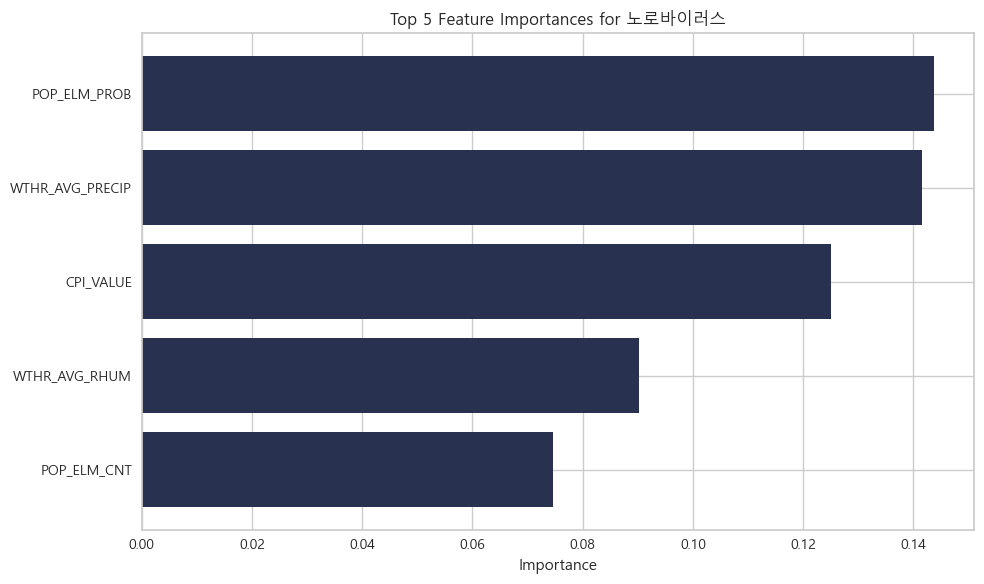

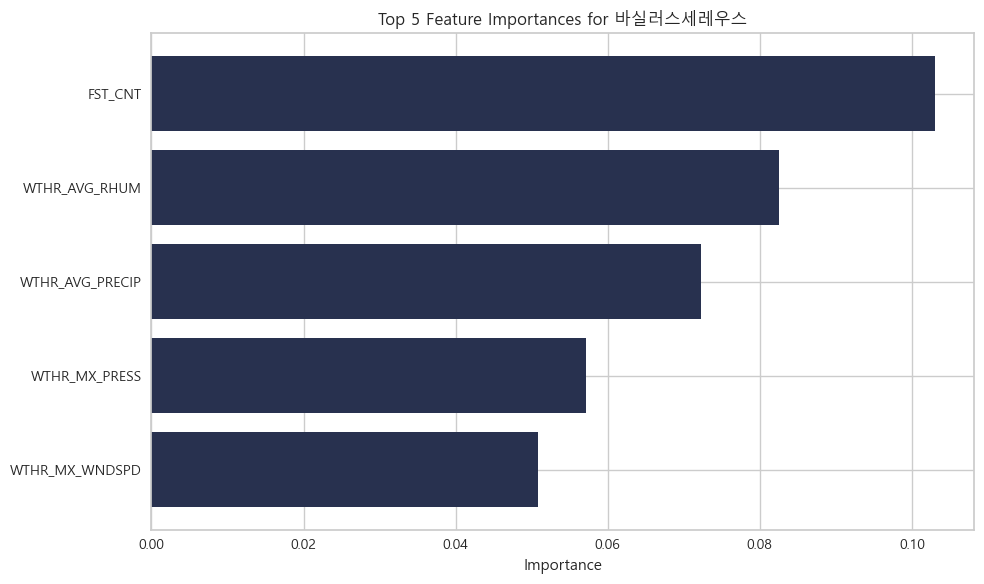

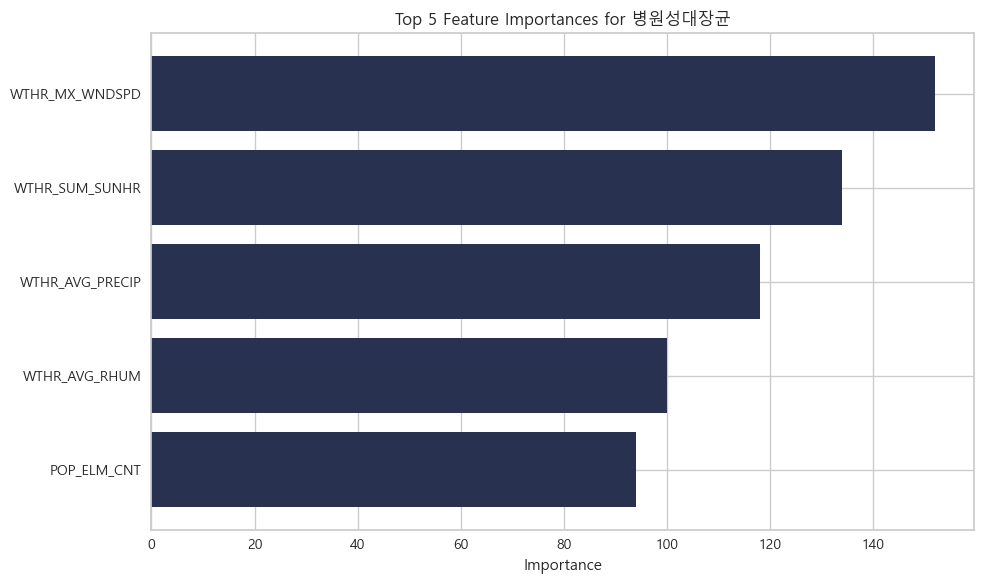

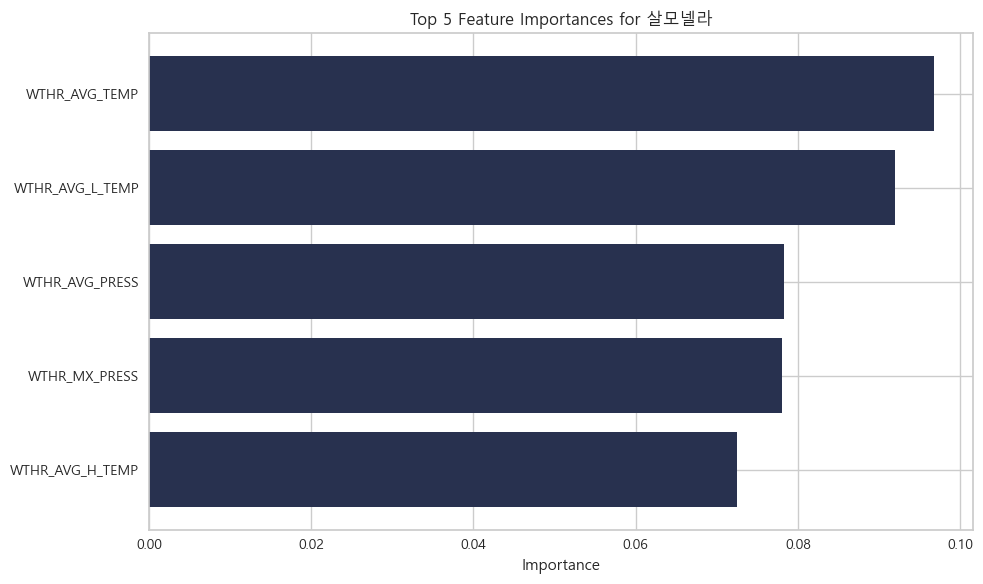

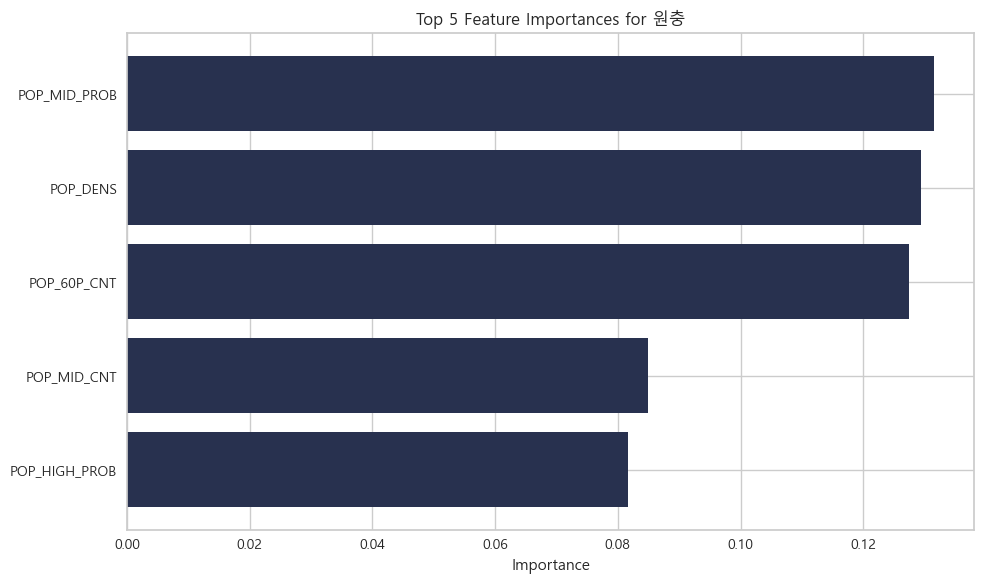

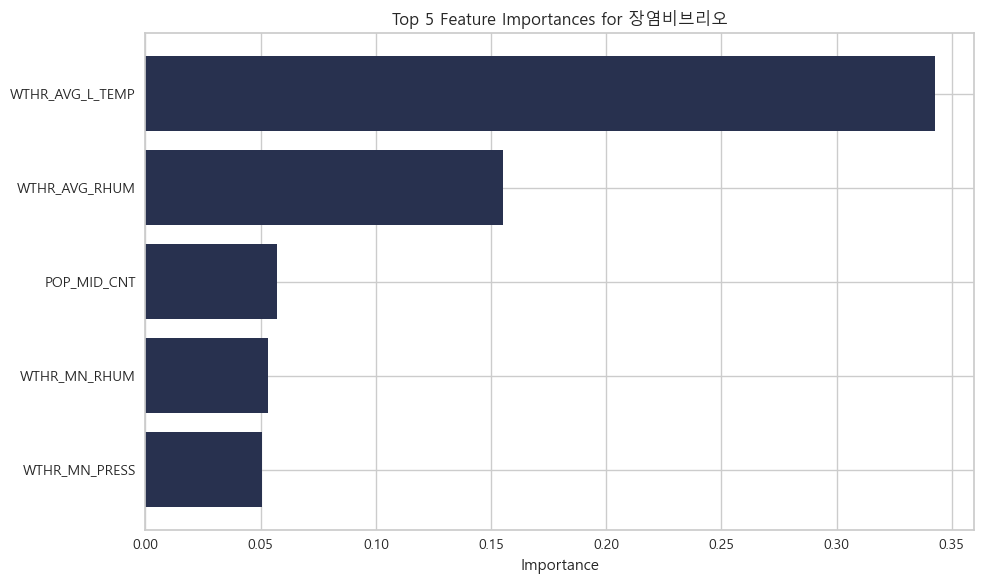

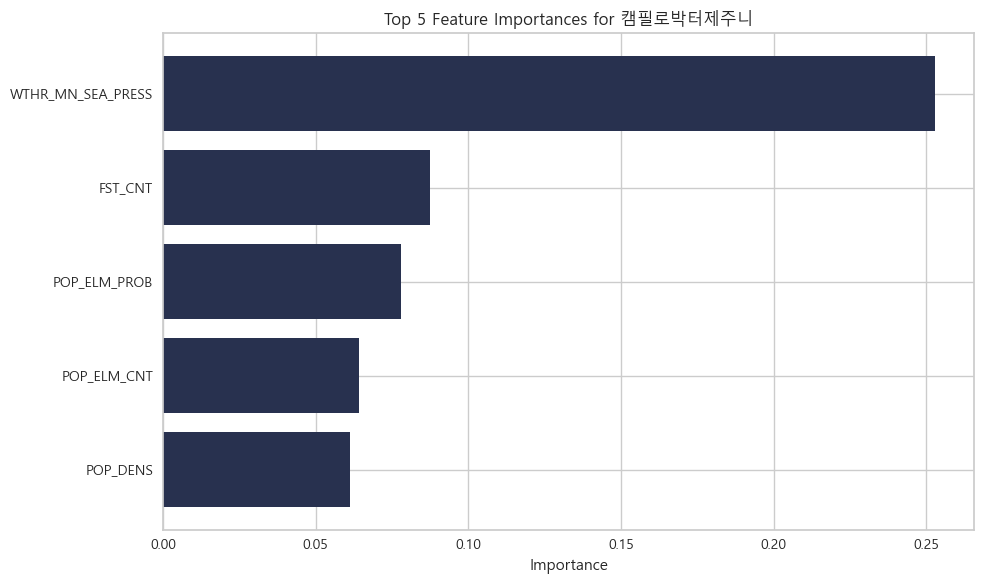

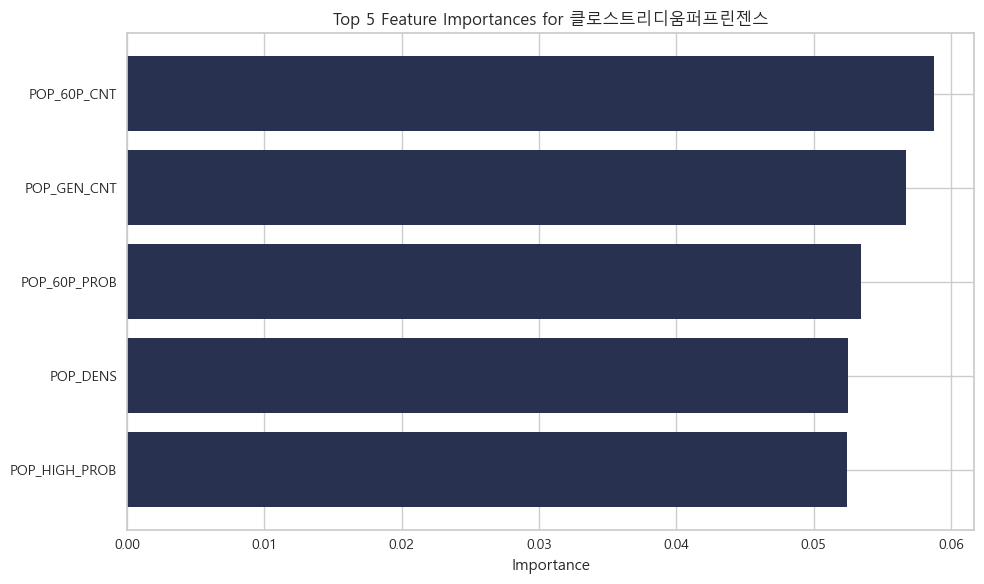

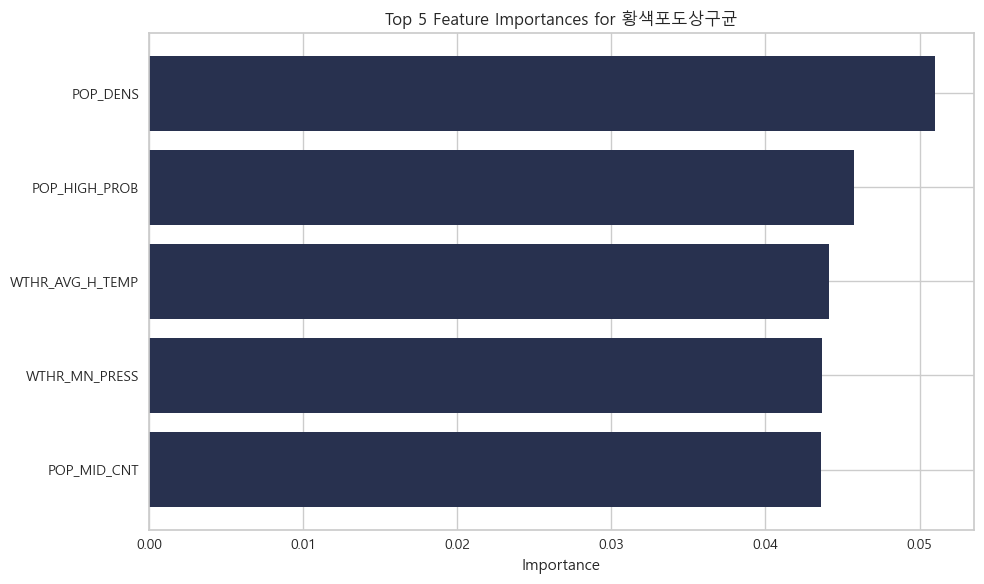

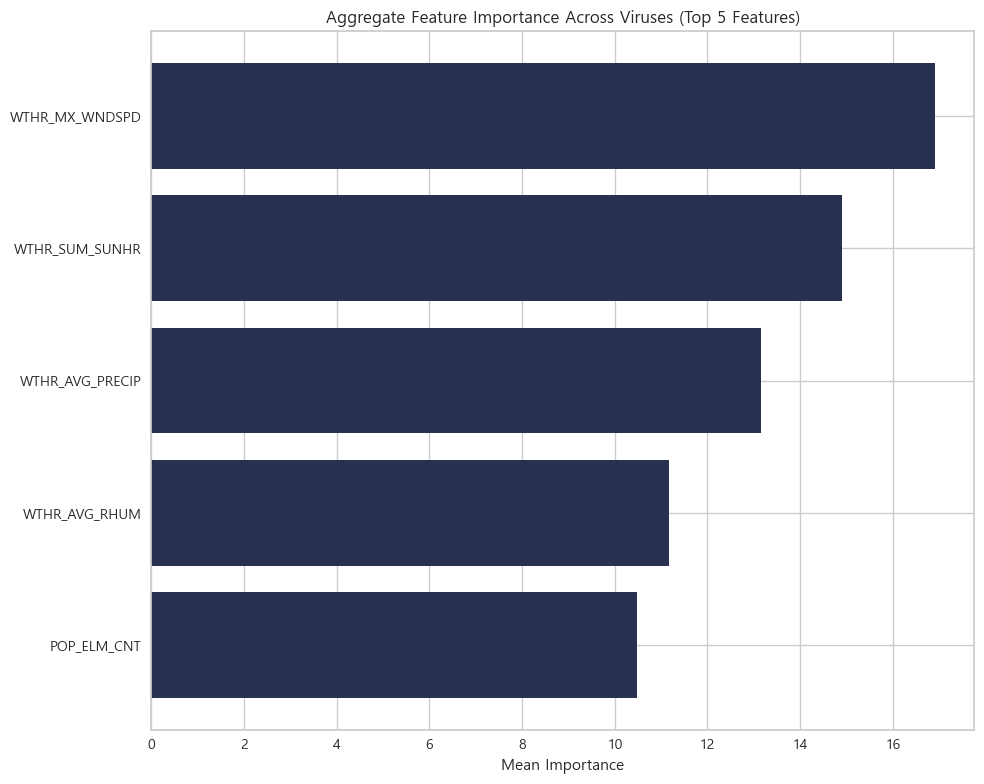

In [60]:
# top 5 feature importance
unique_viruses = top_features_by_virus['Virus'].unique()

for virus in unique_viruses:
    virus_data = top_features_by_virus[top_features_by_virus['Virus'] == virus]
    plt.figure(figsize=(10, 6))
    plt.barh(virus_data['Feature'], virus_data['Importance'], color='#28314F')
    plt.title(f"Top 5 Feature Importances for {virus}")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# top5 feature importance 평균
plt.figure(figsize=(10, 8))
plt.barh(aggregate_feature_importance['Feature'][:5], aggregate_feature_importance['Importance'][:5], color='#28314F')
plt.title("Aggregate Feature Importance Across Viruses (Top 5 Features)")
plt.xlabel("Mean Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#### 3) ROC Curve 확인

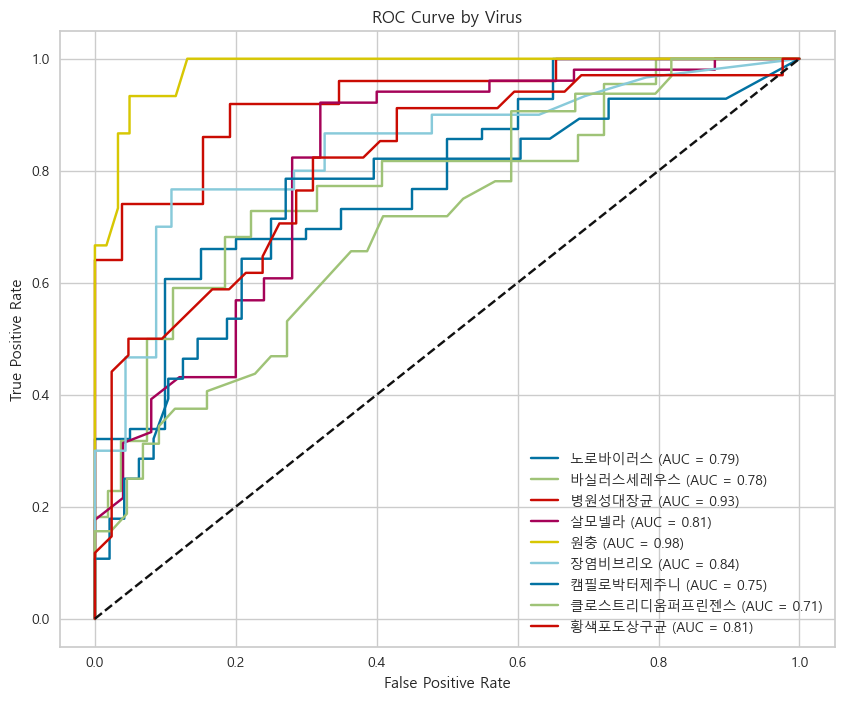

In [61]:
# 각 바이러스의 모델과 이름을 리스트로 가져와 ROC Curve 생성
plt.figure(figsize=(10, 8))
for virus, model_filename in zip(results_df['Virus'], results_df['Model']):
    model_file = f"{virus}_{model_filename}.pkl"
    if os.path.exists(model_file):
        model = joblib.load(model_file)
        
        # 테스트 데이터 준비
        virus_data = data[data['OCCRNC_VIRS'] == virus]
        X = virus_data.drop(columns=['OCCRNC_YEAR', 'OCCRNC_MM', 'OCCRNC_VIRS', 'OCCRNC_CNT', 'OCCRNC_IND', 'PATNT_CNT'])
        y = virus_data['OCCRNC_IND']
        _, X_test, _, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

        # ROC 곡선 그리기 (이진 분류인 경우에만)
        if len(np.unique(y_test)) == 2:
            y_score = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test)
            fpr, tpr, _ = roc_curve(y_test, y_score)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{virus} (AUC = {roc_auc:.2f})")
        else:
            print(f"Skipping ROC curve for {virus} due to multi-class target.")

# 그래프 속성 설정 및 출력
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve by Virus')
plt.legend(loc="lower right")
plt.show()

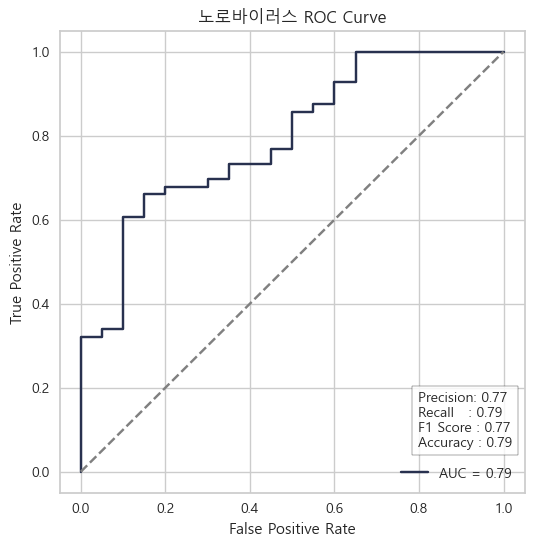

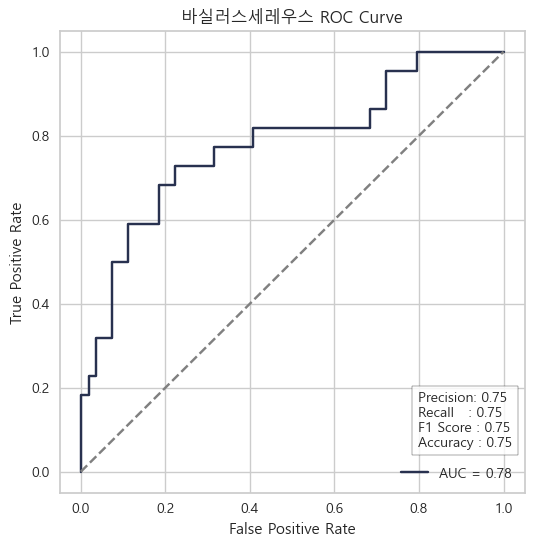

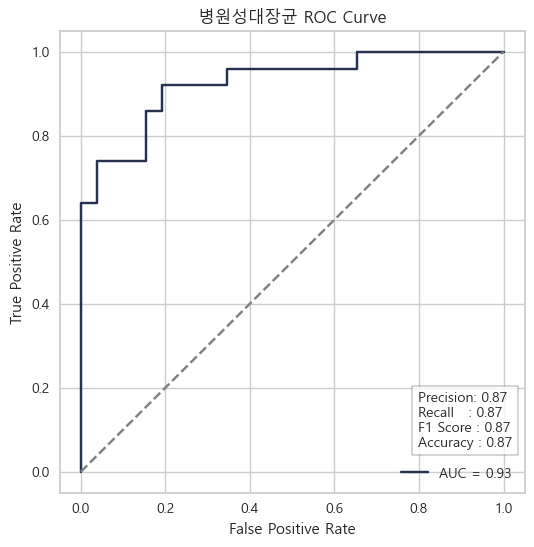

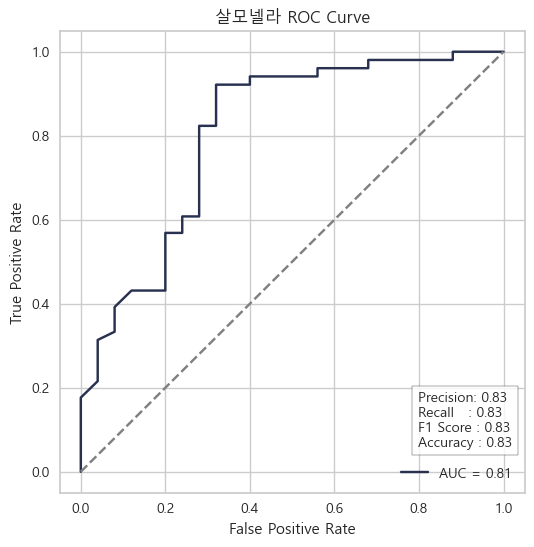

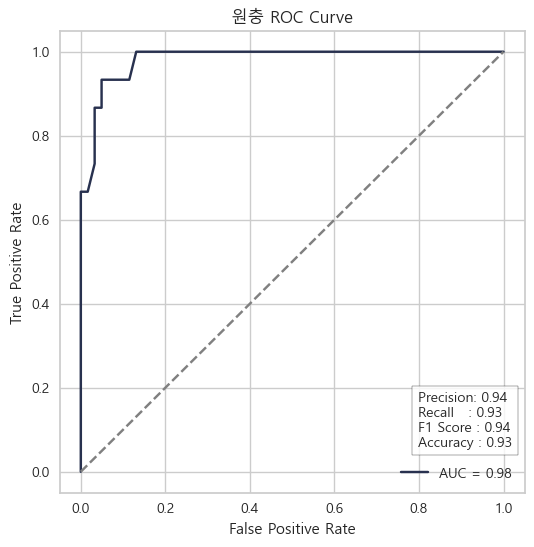

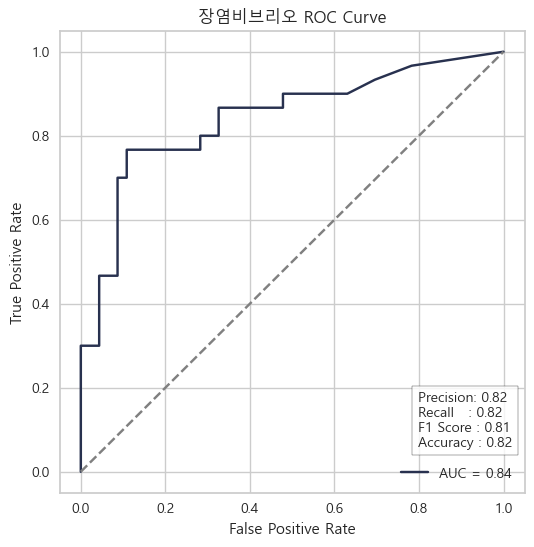

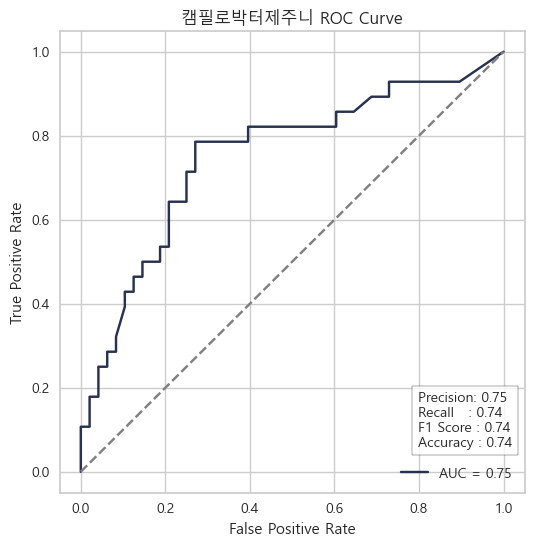

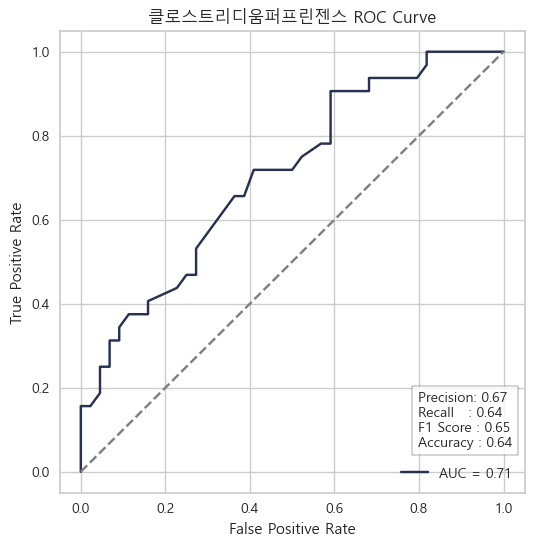

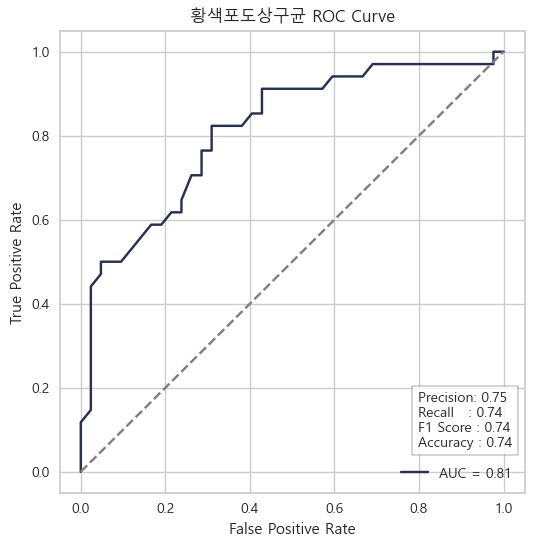

          Virus       AUC  Precision    Recall  F1 Score  Accuracy
0        노로바이러스  0.793750   0.774123  0.789474  0.770175  0.789474
1      바실러스세레우스  0.779461   0.753486  0.750000  0.751610  0.750000
2        병원성대장균  0.926154   0.868421  0.868421  0.868421  0.868421
3          살모넬라  0.807451   0.825824  0.828947  0.825932  0.828947
4            원충  0.982514   0.942302  0.934211  0.936372  0.934211
5        장염비브리오  0.841667   0.817814  0.815789  0.811195  0.815789
6      캠필로박터제주니  0.750744   0.747010  0.736842  0.739893  0.736842
7  클로스트리디움퍼프린젠스  0.706676   0.666275  0.644737  0.646400  0.644737
8       황색포도상구균  0.813375   0.753354  0.736842  0.736842  0.736842


In [62]:
# 초기화
metrics_results = []

# 원인물질별 모델 가져오기
viruses = results_df['Virus'].tolist()
model_files = [f"{virus}_{results_df[results_df['Virus'] == virus]['Model'].values[0]}.pkl" for virus in viruses]

for virus, model_file in zip(viruses, model_files):
    if os.path.exists(model_file):
        model = joblib.load(model_file)
        
        # test 설정
        virus_data = data[data['OCCRNC_VIRS'] == virus]
        X = virus_data.drop(columns=['OCCRNC_YEAR', 'OCCRNC_MM', 'OCCRNC_VIRS', 'OCCRNC_CNT', 'OCCRNC_IND', 'PATNT_CNT'])
        y = virus_data['OCCRNC_IND']
        _, X_test, _, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

        # 이진 분류인 경우에만 그림
        if len(np.unique(y_test)) == 2:
            y_pred = model.predict(X_test)
            y_score = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_score)
            roc_auc = auc(fpr, tpr)
            
            precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
            recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
            f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
            accuracy = accuracy_score(y_test, y_pred)

            # 저장
            metrics_results.append({
                'Virus': virus,
                'AUC': roc_auc,
                'Precision': precision,
                'Recall': recall,
                'F1 Score': f1,
                'Accuracy': accuracy
            })
            
            # 시각화
            plt.figure(figsize=(6, 6))
            plt.plot(fpr, tpr, color='#28314F',label=f"AUC = {roc_auc:.2f}")
            plt.plot([0, 1], [0, 1],color='gray', linestyle='--' )
            plt.title(f"{virus} ROC Curve")
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.legend(loc="lower right")
            
            # 텍스트 박스
            text_str = (f"Precision: {precision:.2f}\n"
                        f"Recall   : {recall:.2f}\n"
                        f"F1 Score : {f1:.2f}\n"
                        f"Accuracy : {accuracy:.2f}")

            plt.gca().text(0.77, 0.22, text_str, fontsize=10, ha='left', va='top', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))

            plt.show()

# Convert results to DataFrame and display
metrics_df = pd.DataFrame(metrics_results)
print(metrics_df)

## 4. 시계열 모델링

In [63]:
from prophet import Prophet
import pandas as pd
from sklearn.metrics import r2_score

class ProphetPredictor:
    def __init__(self, periods):
        self.periods = periods
        self.models = {}
        self.r2_scores = {}

    def fit(self, data):
        self.data_columns = data.columns
        for column in data.columns:
            df = data[[column]].reset_index()
            df.columns = ['ds', 'y']
            model = Prophet()
            model.fit(df)
            self.models[column] = model

    def predict(self):
        future_predictions = pd.DataFrame()
        
        for column, model in self.models.items():
            future = model.make_future_dataframe(periods=self.periods, freq='M')
            forecast = model.predict(future)
            future_values = forecast[['ds', 'yhat']].tail(self.periods).set_index('ds')
            future_predictions[column] = future_values['yhat']
        
        return future_predictions

    def evaluate(self, data):
        for column, model in self.models.items():
            df = data[[column]].reset_index()
            df.columns = ['ds', 'y']
            forecast = model.predict(df)
            
            y_true = df['y']
            y_pred = forecast['yhat']
            
            valid_index = y_true.notna() & y_pred.notna()
            y_true = y_true[valid_index]
            y_pred = y_pred[valid_index]
            
            if len(y_true) > 0:
                self.r2_scores[column] = r2_score(y_true, y_pred)
            else:
                self.r2_scores[column] = None  
        return self.r2_scores
